# Synthèse et analyse des résultats

FRECHOU Damien

## Sommaire

- Importation des données
- Structuration des données
- Calcul



In [1]:
import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# import joblib
# YYY = joblib.load(r"./YYY") 

# # YYY = [Y_test, Y_new, Y_hs, Y_yolo, Y_annotation]
# # Y_test = [y_labels,y_pred,y_proba]

# yyy = YYY[2:5]

In [3]:
import joblib
YYYY = joblib.load(r"./YYYY") 

# YYYY = [Y_test, Y_new, Y_hs, Y_yolo, Y_annotation]
# Y_test = [y_proba, y_pred, y_labels, list_y_proba_class]

yyyy = YYYY[2:5]

In [4]:
len(yyyy)

3

In [5]:
# import joblib
# cr_test = joblib.load(r"./classification_report_list") # ou "classification_report_list"
# # cllassification_report
# # precision_recall_fscore_support
# # support: number of samples for a specific class

In [6]:
# from sklearn.metrics import classification_report
# print(classification_report(y_labels, y_pred))

In [7]:
list_methods = ['baseline', 'yolo', 'annotation']

### Accuracy

In [8]:
from sklearn.metrics import accuracy_score

accuracy_list = []

for i in range(len(yyyy)):
    y_accuracy = accuracy_score(yyyy[i][1], yyyy[i][2], normalize=True)
    accuracy_list.append(y_accuracy)
    print("L'accuracy score pour la méthose " + list_methods[i] + " donne: " + str(y_accuracy))

L'accuracy score pour la méthose baseline donne: 0.8104288499025342
L'accuracy score pour la méthose yolo donne: 0.8132837900603809
L'accuracy score pour la méthose annotation donne: 0.8419854280510018


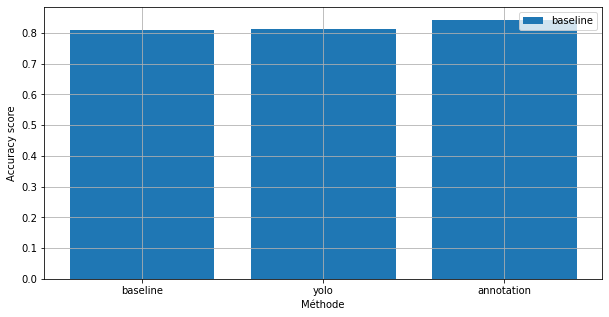

In [9]:
plt.figure(figsize=(10,5))
plt.bar(list_methods,accuracy_list)
plt.xlabel("Méthode")
plt.ylabel('Accuracy score')
plt.legend(['baseline','yolo','annotation'])
plt.grid()
# plt.text(list_methods,accuracy_list,['ab','f','r'])

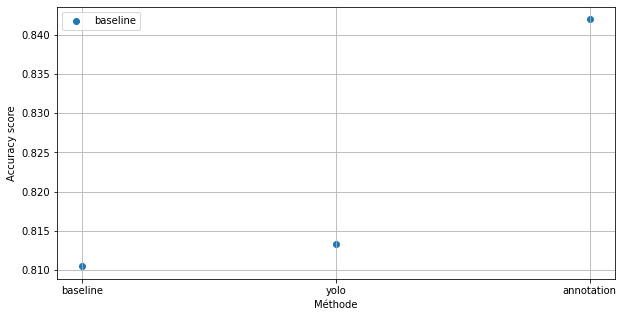

In [10]:
plt.figure(figsize=(10,5))
plt.scatter(list_methods,accuracy_list)
plt.xlabel("Méthode")
plt.ylabel('Accuracy score')
# plt.legend(['baseline','yolo','annotation'])
plt.grid()
# plt.text(list_methods,accuracy_list,['ab','f','r'])

In [12]:
from sklearn.metrics import precision_recall_fscore_support
# cllassification_report =  precision_recall_fscore_support

cr_list = []

for i in range(len(yyyy)):
    cr_ds_test = precision_recall_fscore_support(yyyy[i][2],yyyy[i][1],average=None)
    cr_list.append(cr_ds_test)

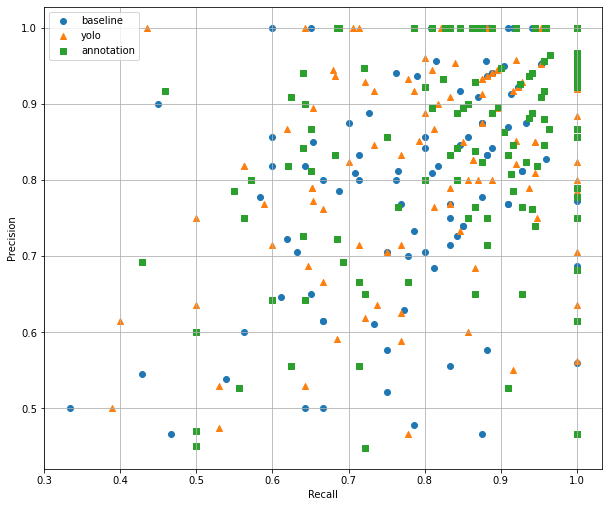

In [13]:
plt.figure(figsize=(10,10))
plt.scatter(cr_list[0][1],cr_list[0][0])#, c= cr_list[0][3] )
plt.scatter(cr_list[1][1],cr_list[1][0],marker="^")
plt.scatter(cr_list[2][1],cr_list[2][0],marker="s")
plt.xlabel("Recall")
plt.ylabel('Precision')
# plt.xlim([0,1])
# plt.ylim([0,1])
plt.legend(['baseline','yolo','annotation'])
plt.grid()
plt.gca().set_aspect('equal', adjustable='box') #  equalize the scales of x-axis and y-axis

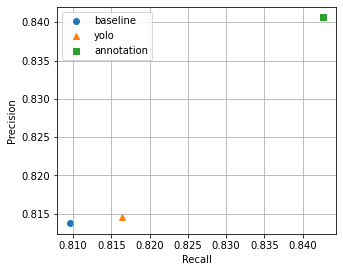

In [14]:
plt.figure(figsize=(5,5))
plt.scatter(np.mean(cr_list[0][1]),np.mean(cr_list[0][0]))#, c= cr_test[0][3] )
plt.scatter(np.mean(cr_list[1][1]),np.mean(cr_list[1][0]),marker="^")
plt.scatter(np.mean(cr_list[2][1]),np.mean(cr_list[2][0]),marker="s")
plt.xlabel("Recall")
plt.ylabel('Precision')
# plt.xlim([0,1])
# plt.ylim([0,1])
plt.legend(['baseline','yolo','annotation'])
plt.grid()
plt.gca().set_aspect('equal', adjustable='box') #  equalize the scales of x-axis and y-axis

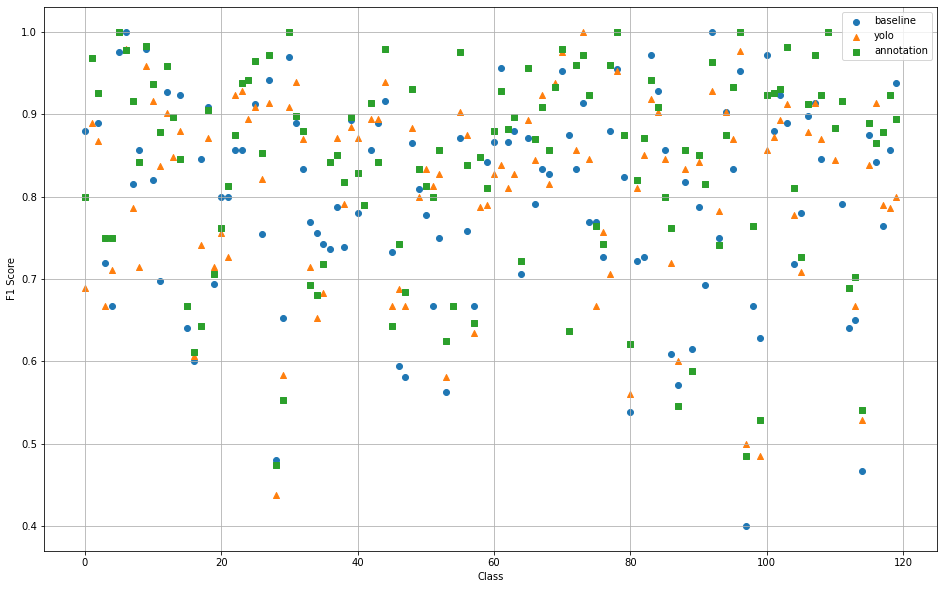

In [155]:
plt.figure(figsize=(16,10))
plt.scatter(range(len(cr_list[0][2])),cr_list[0][2])#, c= cr_list[0][3] )
plt.scatter(range(len(cr_list[1][2])),cr_list[1][2],marker="^")
plt.scatter(range(len(cr_list[2][2])),cr_list[2][2],marker="s")
plt.xlabel("Class")
plt.ylabel('F1 Score')
# plt.xlim([0,1])
# plt.ylim([0,1])
plt.legend(['baseline','yolo','annotation'])
plt.grid()
# plt.gca().set_aspect('equal', adjustable='box') #  equalize the scales of x-axis and y-axis

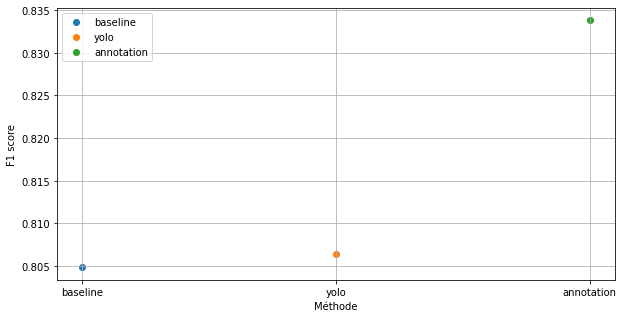

In [156]:
plt.figure(figsize=(10,5))
plt.scatter(list_methods[0],np.mean(cr_list[0][2]))
plt.scatter(list_methods[1],np.mean(cr_list[1][2]))
plt.scatter(list_methods[2],np.mean(cr_list[2][2]))
plt.xlabel("Méthode")
plt.ylabel('F1 score')
plt.legend(['baseline','yolo','annotation'])
plt.grid()
# plt.text(list_methods,accuracy_list,['ab','f','r'])

In [197]:
# plt.figure(figsize=(16,10))
# plt.scatter(range(len(cr_list[0][1])),cr_list[0][0])#, c= cr_list[0][3] )
# plt.scatter(range(len(cr_list[1][1])),cr_list[1][0],marker="^")
# plt.scatter(range(len(cr_list[2][1])),cr_list[2][0],marker="s")
# plt.xlabel("Class")
# plt.ylabel('Precision')
# # plt.xlim([0,1])
# # plt.ylim([0,1])
# plt.legend(['baseline','yolo','annotation'])
# plt.grid()
# # plt.gca().set_aspect('equal', adjustable='box') #  equalize the scales of x-axis and y-axis

In [196]:
# plt.figure(figsize=(16,10))
# plt.plot(range(len(cr_list[0][1])),cr_list[0][0])#, c= cr_list[0][3] )
# plt.plot(range(len(cr_list[1][1])),cr_list[1][0],marker="^")
# plt.plot(range(len(cr_list[2][1])),cr_list[2][0],marker="s")
# plt.xlabel("Class")
# plt.ylabel('Precision')
# # plt.xlim([0,1])
# # plt.ylim([0,1])
# plt.legend(['baseline','yolo','annotation'])
# plt.grid()
# # plt.gca().set_aspect('equal', adjustable='box') #  equalize the scales of x-axis and y-axis

In [193]:
# plt.figure(figsize=(16,10))
# plt.scatter(range(len(cr_list[0][1])),cr_list[0][1])#, c= cr_list[0][3] )
# plt.scatter(range(len(cr_list[1][1])),cr_list[1][1],marker="^")
# plt.scatter(range(len(cr_list[2][1])),cr_list[2][1],marker="s")
# plt.xlabel("Class")
# plt.ylabel('Recall')
# # plt.xlim([0,1])
# # plt.ylim([0,1])
# plt.legend(['baseline','yolo','annotation'])
# plt.grid()
# # plt.gca().set_aspect('equal', adjustable='box') #  equalize the scales of x-axis and y-axis

In [194]:
# plt.figure(figsize=(16,10))
# plt.plot(range(len(cr_list[0][1])),cr_list[0][1])#, c= cr_list[0][3] )
# plt.plot(range(len(cr_list[1][1])),cr_list[1][1],marker="^")
# plt.plot(range(len(cr_list[2][1])),cr_list[2][1],marker="s")
# plt.xlabel("Class")
# plt.ylabel('Recall')
# # plt.xlim([0,1])
# # plt.ylim([0,1])
# plt.legend(['baseline','yolo','annotation'])
# plt.grid()
# # plt.gca().set_aspect('equal', adjustable='box') #  equalize the scales of x-axis and y-axis

### Dataframe

In [19]:
df_precision = pd.DataFrame()

for i in range(len(list_methods)):
    df_precision[list_methods[i]] = cr_list[i][0]
df_precision

,baseline,yolo,annotation
0,1.000000,0.625000,0.750000
1,0.937500,0.800000,0.937500
2,0.827586,0.821429,0.925926
3,0.818182,0.818182,0.900000
4,0.722222,0.761905,0.833333
...,...,...,...
115,0.875000,0.866667,0.888889
116,0.941176,0.941176,0.888889
117,0.764706,0.937500,0.900000
118,0.833333,0.733333,0.947368


In [20]:
df_recall = pd.DataFrame()

for i in range(len(list_methods)):
    df_recall[list_methods[i]] = cr_list[i][1]
df_recall

,baseline,yolo,annotation
0,0.785714,0.769231,0.857143
1,1.000000,1.000000,1.000000
2,0.960000,0.920000,0.925926
3,0.642857,0.562500,0.642857
4,0.619048,0.666667,0.681818
...,...,...,...
115,0.875000,0.812500,0.888889
116,0.761905,0.888889,0.842105
117,0.764706,0.681818,0.857143
118,0.882353,0.846154,0.900000


In [21]:
df_fscore = pd.DataFrame()

for i in range(len(list_methods)):
    df_fscore[list_methods[i]] = cr_list[i][2]
df_fscore

,baseline,yolo,annotation
0,0.880000,0.689655,0.800000
1,0.967742,0.888889,0.967742
2,0.888889,0.867925,0.925926
3,0.720000,0.666667,0.750000
4,0.666667,0.711111,0.750000
...,...,...,...
115,0.875000,0.838710,0.888889
116,0.842105,0.914286,0.864865
117,0.764706,0.789474,0.878049
118,0.857143,0.785714,0.923077


In [22]:
df_support = pd.DataFrame()

for i in range(len(list_methods)):
    df_support[list_methods[i]] = cr_list[i][3]
df_support

,baseline,yolo,annotation
0,14,13,14
1,15,16,15
2,25,25,27
3,14,16,14
4,21,24,22
...,...,...,...
115,16,16,18
116,21,18,19
117,17,22,21
118,17,13,20


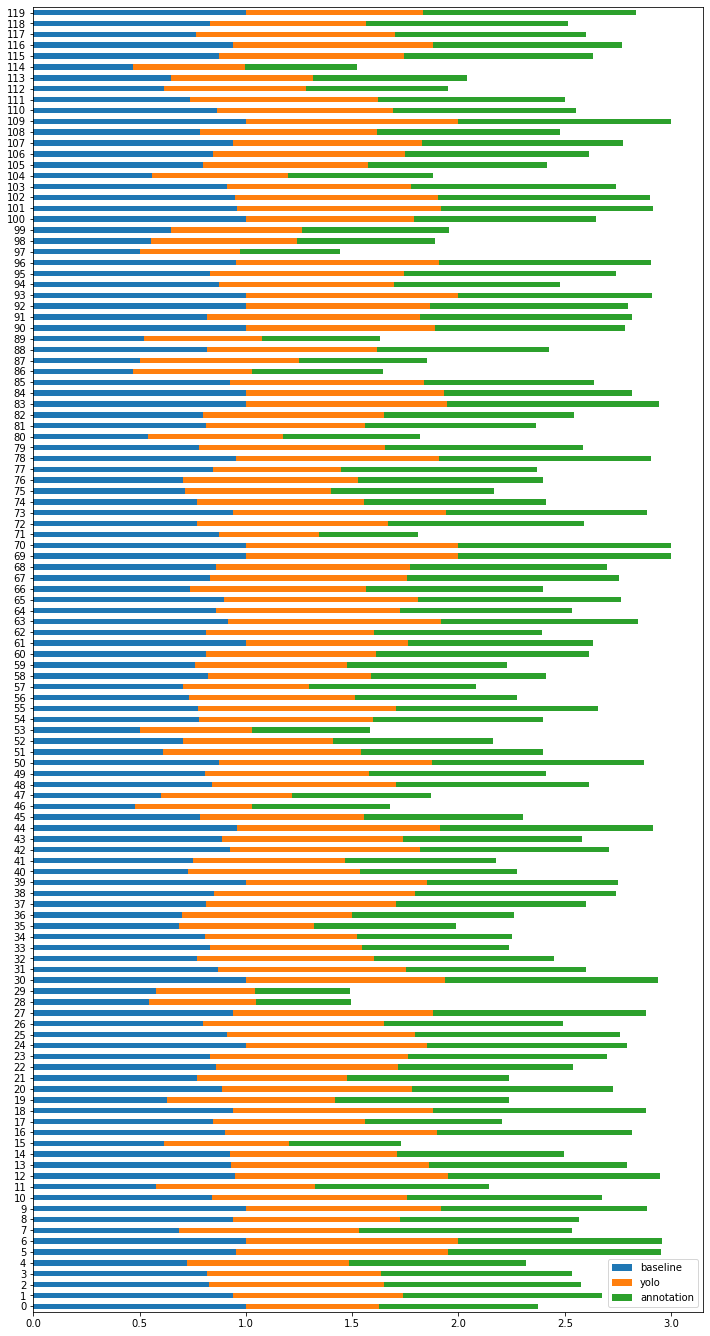

In [23]:
df_precision.plot.barh(stacked=True,figsize=(12,24))
plt.show()

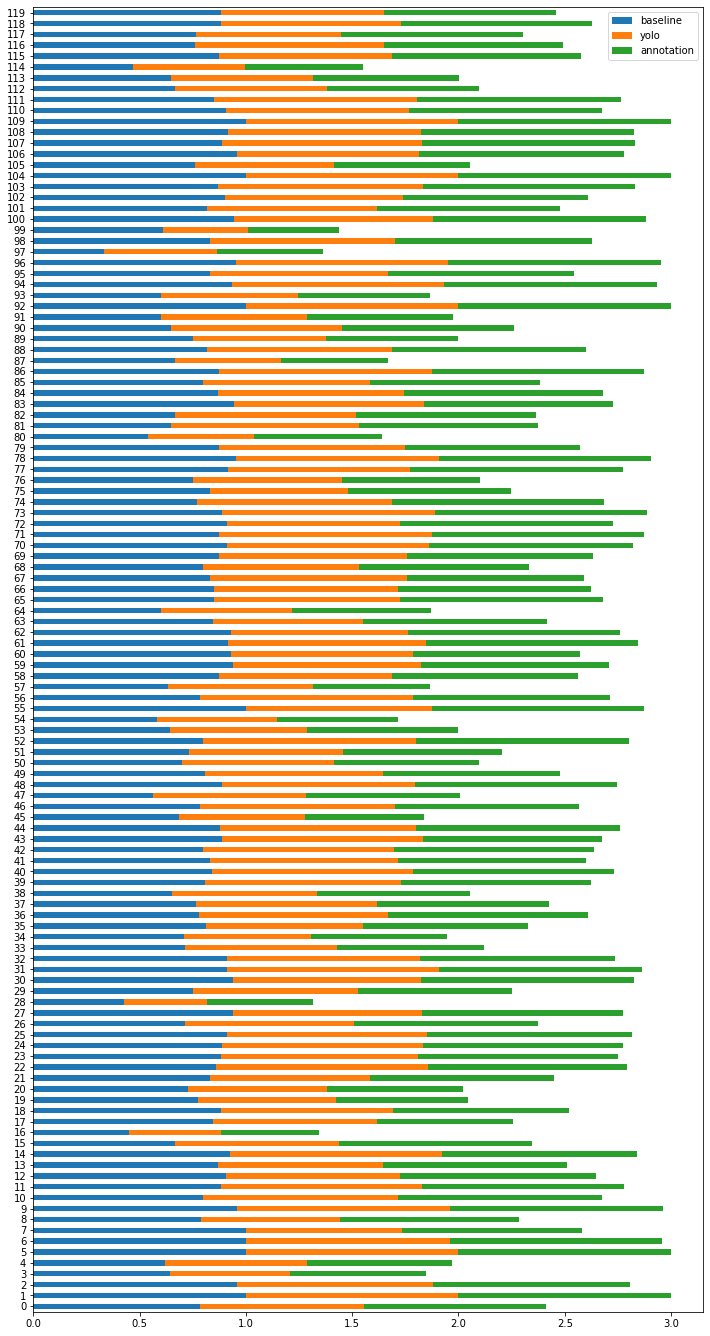

In [24]:
df_recall.plot.barh(stacked=True,figsize=(12,24))
plt.show()

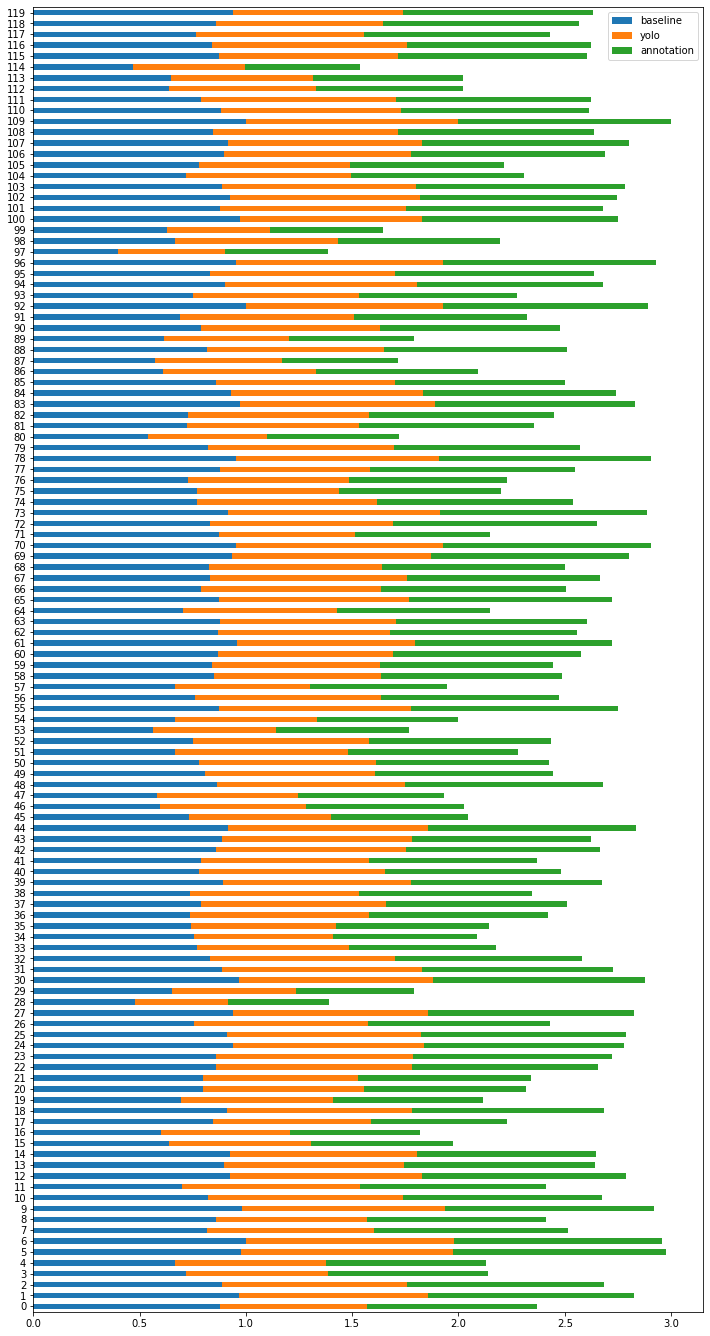

In [25]:
df_fscore.plot.barh(stacked=True,figsize=(12,24))
plt.show()

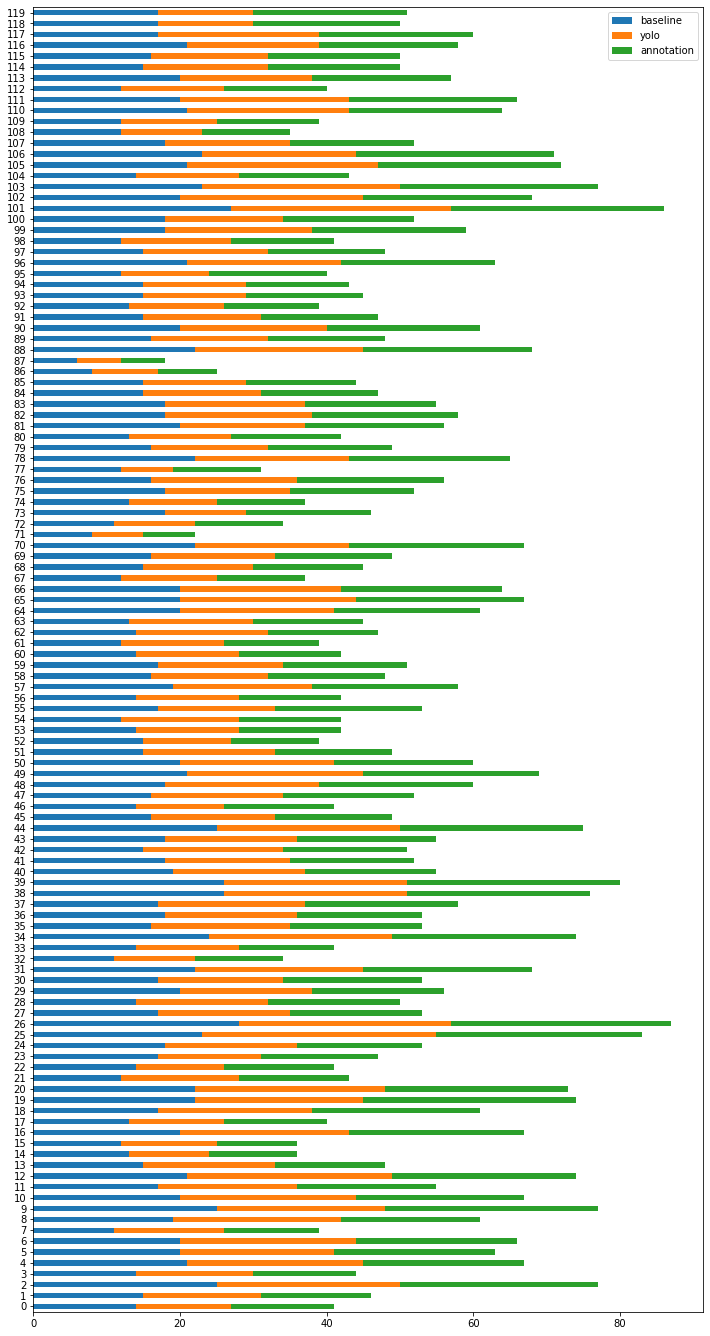

In [26]:
df_support.plot.barh(stacked=True,figsize=(12,24))
plt.show()

### Champ des probabilités

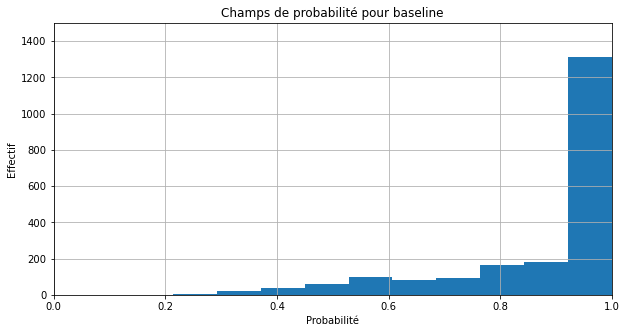

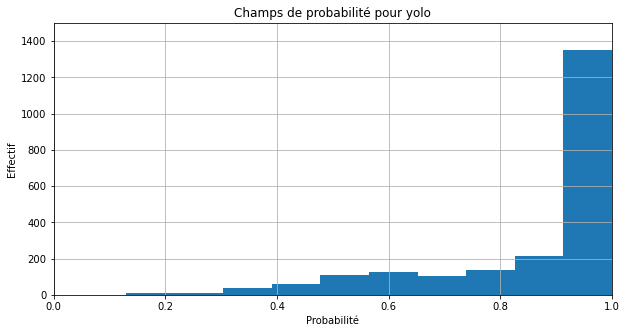

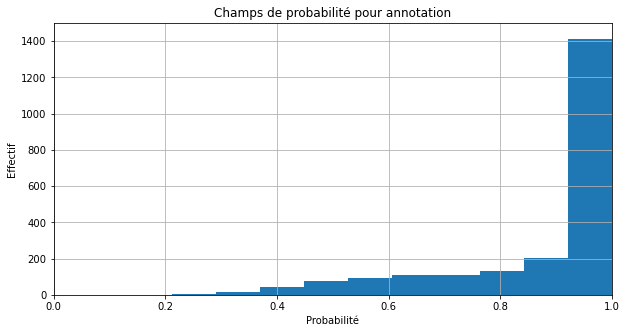

In [27]:
for i in range(len(yyyy)):
    plt.figure(figsize=(10,5))
    plt.title('Champs de probabilité pour ' + list_methods[i])
    plt.hist(yyyy[i][0])
    plt.xlabel('Probabilité')
    plt.ylabel('Effectif')
    plt.xlim([0,1])
    plt.ylim([0,1500])
    plt.grid()

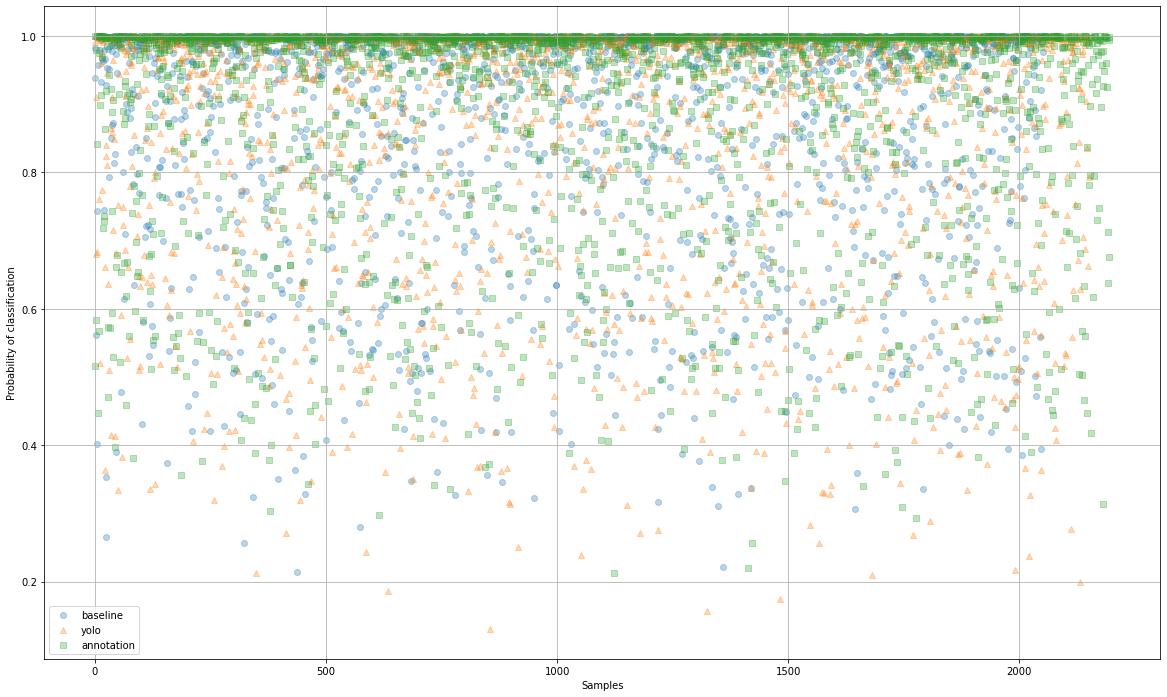

In [28]:
plt.figure(figsize=(20,12))
plt.scatter(range(len(yyyy[0][0])),np.array(yyyy[0][0]),alpha=0.3)
plt.scatter(range(len(yyyy[1][0])),np.array(yyyy[1][0]),marker="^",alpha=0.3)
plt.scatter(range(len(yyyy[2][0])),np.array(yyyy[2][0]),marker="s",alpha=0.3)
plt.xlabel("Samples")
plt.ylabel('Probability of classification')
plt.legend(['baseline','yolo','annotation'])
plt.grid()

In [29]:

# for i in range(len(yyyy)):
#     sns.relplot(data=df_y,x='y_labels',y='y_pred',hue='list_good_pred', palette="tab10",height=8, aspect=1) # markers=["P", "o", "v"]
#     plt.title('Répartiton des labels')
#     plt.grid()
#     plt.show()

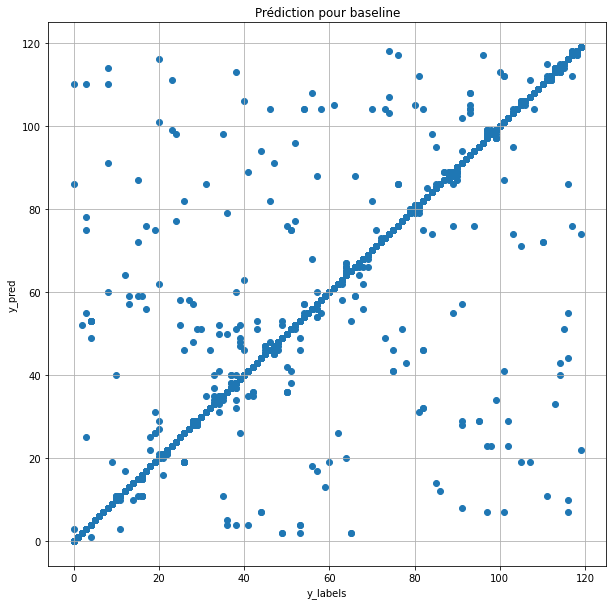

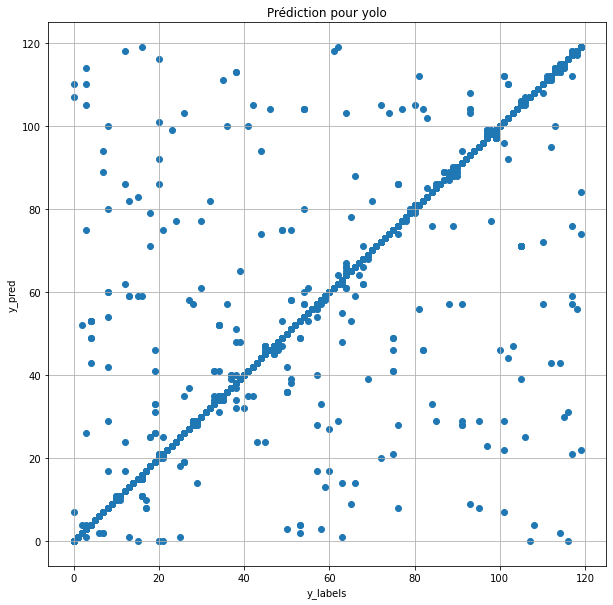

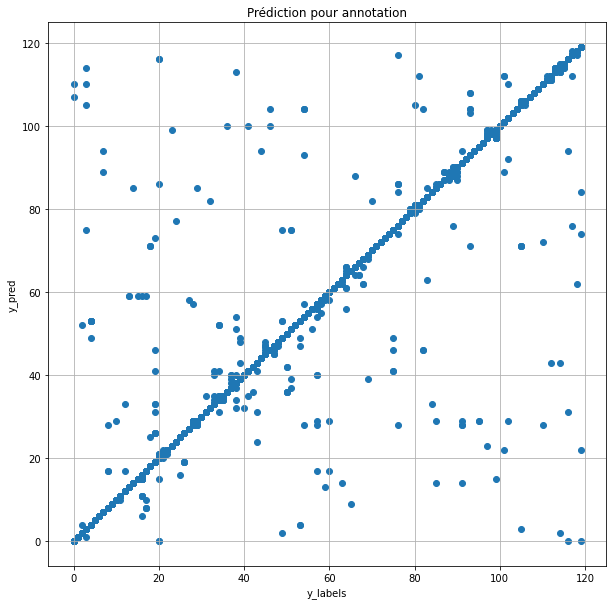

In [30]:
for i in range(len(yyyy)):
    plt.figure(figsize=(10,10))
    plt.title('Prédiction pour ' + list_methods[i])
    plt.scatter(yyyy[i][2],yyyy[i][1])
    plt.xlabel('y_labels')
    plt.ylabel('y_pred')
#     plt.xlim([0,1])
#     plt.ylim([0,1500])
    plt.grid()

In [198]:
# plt.figure(figsize=(10,10))
# # plt.title('Prédiction pour ' + list_methods[i])
# plt.scatter(yyyy[0][2],yyyy[0][1],alpha=0.3)
# plt.scatter(yyyy[1][2],yyyy[1][1],marker="^",alpha=0.3)
# plt.scatter(yyyy[2][2],yyyy[2][1],marker="s",alpha=0.3)
# plt.xlabel('y_labels')
# plt.ylabel('y_pred')
# plt.legend(['baseline','yolo','annotation'])
# #     plt.xlim([0,1])
# #     plt.ylim([0,1500])
# plt.grid()

### Etude sur les images et boundings box

In [32]:
## Import des données brutes et analyse de leur architecture

# path_csv = r'D:\Utilisateurs\Damien\Documents\Test_code\test_python\OCR_projets\IML\P7_' 
path_csv = r'C:\Users\daims\Mon Drive\Projet_dvlpt\Cours_dvlpt\OCR\P7_'

data_yolo_dog = pd.read_csv(path_csv + r'\data_yolo_dog.csv',sep=",",low_memory=False)
df_yolo_dog_detect = pd.read_csv(path_csv + r'\df_yolo_dog_detect.csv',sep=",",low_memory=False)
df_dog_annotation = pd.read_csv(path_csv + r'\df_dog_annotation.csv',sep=",",low_memory=False)


In [33]:
data_yolo_dog

,file_name,class_yolo,xpm,ypm,xpw,yph,probability
0,n02097130_2821,16,0.500000,0.528000,0.996000,0.933333,0.958085
1,n02097130_5891,16,0.505000,0.464000,0.674000,0.869333,0.967097
2,n02106382_865,16,0.656818,0.490909,0.686364,0.981818,0.514949
3,n02106382_865,21,0.654545,0.490909,0.681818,0.981818,0.588825
4,n02097130_4265,16,0.463000,0.480000,0.830000,0.704000,0.338776
...,...,...,...,...,...,...,...
4263,n02112018_1158,16,0.641000,0.743017,0.702000,0.497207,0.888464
4264,n02112018_1158,16,0.204000,0.509777,0.368000,0.958101,0.916298
4265,n02112018_354,14,0.555556,0.486726,0.883333,0.805310,0.387610
4266,n02112018_354,16,0.551389,0.493363,0.897222,0.809735,0.536818


In [34]:
df_yolo_dog_detect

,file_name,class_yolo,xpm,ypm,xpw,yph,probability
0,n02097130_2821,16,0.500000,0.528000,0.996000,0.933333,0.958085
1,n02097130_5891,16,0.505000,0.464000,0.674000,0.869333,0.967097
2,n02106382_865,16,0.656818,0.490909,0.686364,0.981818,0.514949
3,n02097130_4265,16,0.463000,0.480000,0.830000,0.704000,0.338776
4,n02097130_4518,16,0.479000,0.513000,0.950000,0.974000,0.945232
...,...,...,...,...,...,...,...
2148,n02112018_12953,16,0.462000,0.562667,0.292000,0.485333,0.935491
2149,n02112018_1158,16,0.641000,0.743017,0.702000,0.497207,0.888464
2150,n02112018_1158,16,0.204000,0.509777,0.368000,0.958101,0.916298
2151,n02112018_354,16,0.551389,0.493363,0.897222,0.809735,0.536818


In [35]:
df_dog_annotation

,file_name,xmin,ymin,xmax,ymax,name_race,width,height,class_string,path_to_img,nb_race
0,n02091635_1634,278,150,705,439,otterhound,800,533,n02091635,/kaggle/input/dog-race-images/images/images/n0...,2
1,n02091635_1634,121,178,342,427,otterhound,800,533,n02091635,/kaggle/input/dog-race-images/images/images/n0...,2
2,n02091635_4626,16,34,147,179,otterhound,200,200,n02091635,/kaggle/input/dog-race-images/images/images/n0...,1
3,n02091635_3916,42,17,194,246,otterhound,240,250,n02091635,/kaggle/input/dog-race-images/images/images/n0...,1
4,n02091635_386,70,36,348,279,otterhound,360,308,n02091635,/kaggle/input/dog-race-images/images/images/n0...,1
...,...,...,...,...,...,...,...,...,...,...,...
22121,n02088466_8289,60,43,301,457,bloodhound,375,500,n02088466,/kaggle/input/dog-race-images/images/images/n0...,1
22122,n02088466_7015,179,54,324,372,bloodhound,500,375,n02088466,/kaggle/input/dog-race-images/images/images/n0...,1
22123,n02088466_7429,35,17,198,308,bloodhound,294,320,n02088466,/kaggle/input/dog-race-images/images/images/n0...,1
22124,n02088466_8831,234,154,284,231,bloodhound,500,333,n02088466,/kaggle/input/dog-race-images/images/images/n0...,1


#### Plan d'organisation pour le calcul du IOU


- Récupérer le nombre de chiens détetctés ou annotés dans chaque images.
- Filtrer les images n'ayant qu'un seul chien.
- Itérer sur la liste des noms uniques des images du dataset (de test), et récupérer les coordonnées correspondantes.
- Prendre en compte les effets d'échelles et de proportion entre images (224x224 ou non, taille original de l'image ou non, proportions en % ou coins, ...).
- Effectuer le calcul du IOU pour chque nom de la liste. 

Penser si possible, à récupérer ou reconstruire le chemin des images (chemins ds_test, et chemi sous ds_test_yolo/annotation)

#### Récupération du nombre de chiens dans une image

In [36]:
# df_count = df_dog_annotation.groupby("file_name",sort=True).count().sort_values(by="name_race", ascending=False)
# df_count

In [37]:
#df_count['name_race'].value_counts()

In [38]:
# df_dog_annotation['nb_race'] = df_dog_annotation.groupby("file_name",sort=True)['name_race'].transform('count')
# df_dog_annotation

In [39]:
df_dog_annotation[df_dog_annotation["nb_race"]==1]

,file_name,xmin,ymin,xmax,ymax,name_race,width,height,class_string,path_to_img,nb_race
2,n02091635_4626,16,34,147,179,otterhound,200,200,n02091635,/kaggle/input/dog-race-images/images/images/n0...,1
3,n02091635_3916,42,17,194,246,otterhound,240,250,n02091635,/kaggle/input/dog-race-images/images/images/n0...,1
4,n02091635_386,70,36,348,279,otterhound,360,308,n02091635,/kaggle/input/dog-race-images/images/images/n0...,1
5,n02091635_3521,14,33,385,272,otterhound,406,296,n02091635,/kaggle/input/dog-race-images/images/images/n0...,1
6,n02091635_390,49,8,374,374,otterhound,375,375,n02091635,/kaggle/input/dog-race-images/images/images/n0...,1
...,...,...,...,...,...,...,...,...,...,...,...
22121,n02088466_8289,60,43,301,457,bloodhound,375,500,n02088466,/kaggle/input/dog-race-images/images/images/n0...,1
22122,n02088466_7015,179,54,324,372,bloodhound,500,375,n02088466,/kaggle/input/dog-race-images/images/images/n0...,1
22123,n02088466_7429,35,17,198,308,bloodhound,294,320,n02088466,/kaggle/input/dog-race-images/images/images/n0...,1
22124,n02088466_8831,234,154,284,231,bloodhound,500,333,n02088466,/kaggle/input/dog-race-images/images/images/n0...,1


In [40]:
df_dog_annotation['file_name'].value_counts()

n02106030_18950    6
n02115913_3107     5
n02099601_7588     5
n02097209_1760     4
n02108000_1832     4
                  ..
n02088238_9154     1
n02088238_12563    1
n02088238_9419     1
n02088238_9025     1
n02088466_6775     1
Name: file_name, Length: 20580, dtype: int64

In [41]:
count_dog_yolo = df_yolo_dog_detect['file_name'].value_counts()
count_dog_yolo

n02088466_9167     6
n02111129_314      4
n02087394_7008     4
n02091831_11498    3
n02096294_8268     3
                  ..
n02096294_2408     1
n02096294_7295     1
n02096294_1147     1
n02096294_8557     1
n02112018_1339     1
Name: file_name, Length: 1931, dtype: int64

In [42]:
list_name_count = count_dog_yolo.index.tolist()
list_qty_count = count_dog_yolo.values.tolist()

In [43]:
list_name_count

['n02088466_9167',
 'n02111129_314',
 'n02087394_7008',
 'n02091831_11498',
 'n02096294_8268',
 'n02113186_7231',
 'n02087046_2140',
 'n02090622_8509',
 'n02102973_273',
 'n02101556_4112',
 'n02091831_3616',
 'n02094433_7827',
 'n02110806_4711',
 'n02093256_6158',
 'n02090721_448',
 'n02091032_3564',
 'n02099429_448',
 'n02098105_3387',
 'n02100877_14',
 'n02110185_931',
 'n02101006_2397',
 'n02088632_403',
 'n02095889_6021',
 'n02115641_2440',
 'n02110806_318',
 'n02088238_9778',
 'n02094114_297',
 'n02087394_9922',
 'n02111500_2058',
 'n02097209_3151',
 'n02091032_4245',
 'n02101388_6282',
 'n02091032_6179',
 'n02105505_955',
 'n02111500_241',
 'n02091032_3277',
 'n02094258_1408',
 'n02095889_1847',
 'n02086910_7456',
 'n02113799_5766',
 'n02111500_3746',
 'n02100735_10030',
 'n02100735_1467',
 'n02108551_13042',
 'n02105641_11695',
 'n02092339_6401',
 'n02092339_4936',
 'n02105412_6349',
 'n02095889_2162',
 'n02113712_9682',
 'n02087394_9973',
 'n02110806_5389',
 'n02085936_7574',
 

In [44]:
list_qty_count

[6,
 4,
 4,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [45]:
df_yolo_dog_detect['nb_race'] = [ list_qty_count[list_name_count.index(value)] for value in df_yolo_dog_detect['file_name']]

In [46]:
df_yolo_dog_detect

,file_name,class_yolo,xpm,ypm,xpw,yph,probability,nb_race
0,n02097130_2821,16,0.500000,0.528000,0.996000,0.933333,0.958085,1
1,n02097130_5891,16,0.505000,0.464000,0.674000,0.869333,0.967097,1
2,n02106382_865,16,0.656818,0.490909,0.686364,0.981818,0.514949,1
3,n02097130_4265,16,0.463000,0.480000,0.830000,0.704000,0.338776,1
4,n02097130_4518,16,0.479000,0.513000,0.950000,0.974000,0.945232,1
...,...,...,...,...,...,...,...,...
2148,n02112018_12953,16,0.462000,0.562667,0.292000,0.485333,0.935491,1
2149,n02112018_1158,16,0.641000,0.743017,0.702000,0.497207,0.888464,2
2150,n02112018_1158,16,0.204000,0.509777,0.368000,0.958101,0.916298,2
2151,n02112018_354,16,0.551389,0.493363,0.897222,0.809735,0.536818,1


Répartition du nombre de chiens détecté.

In [47]:
df_yolo_dog_detect['nb_race'].value_counts()

1    1740
2     330
3      69
4       8
6       6
Name: nb_race, dtype: int64

In [48]:
df_yolo_dog_detect[df_yolo_dog_detect["nb_race"]==1]

,file_name,class_yolo,xpm,ypm,xpw,yph,probability,nb_race
0,n02097130_2821,16,0.500000,0.528000,0.996000,0.933333,0.958085,1
1,n02097130_5891,16,0.505000,0.464000,0.674000,0.869333,0.967097,1
2,n02106382_865,16,0.656818,0.490909,0.686364,0.981818,0.514949,1
3,n02097130_4265,16,0.463000,0.480000,0.830000,0.704000,0.338776,1
4,n02097130_4518,16,0.479000,0.513000,0.950000,0.974000,0.945232,1
...,...,...,...,...,...,...,...,...
2146,n02112018_5961,16,0.466000,0.522523,0.928000,0.924925,0.882958,1
2147,n02112018_11105,16,0.411458,0.512500,0.814583,0.869444,0.864450,1
2148,n02112018_12953,16,0.462000,0.562667,0.292000,0.485333,0.935491,1
2151,n02112018_354,16,0.551389,0.493363,0.897222,0.809735,0.536818,1


## Fonctions de calcul pour l'IOU

In [49]:
def bb_intersection_over_union(boxA, boxB):
    # from https://pyimagesearch.com/2016/11/07/intersection-over-union-iou-for-object-detection/
    # Calcul le iou à paritr des coordonnées des coins de deux rectangles (bounding box)
    
    # determine the (x, y)-coordinates of the intersection rectangle
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    # compute the area of intersection rectangle
    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)
    # compute the area of both the prediction and ground-truth
    # rectangles
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)
    # compute the intersection over union by taking the intersection
    # area and dividing it by the sum of prediction + ground-truth
    # areas - the interesection area
    iou = interArea / float(boxAArea + boxBArea - interArea)
    # return the intersection over union value
    return iou

In [50]:
def xm2bb(xm):
    # Convertit le format point milieu + dimension de la bounding box (bb) en format coinn supérieur gauche et inférieur droit
    bbmin_x = xm[0]-xm[2]/2
    bbmin_y = xm[1]-xm[3]/2
    bbmax_x = xm[0]+xm[2]/2
    bbmax_y = xm[1]+xm[3]/2
    
    bb_yolo = [bbmin_x,bbmin_y,bbmax_x,bbmax_y]
    
    return bb_yolo

In [51]:
def xp2xm(xp,w,h):
    # img.shape = (h,w,3)
    #transfo =[[img.shape[1],0,0,0],[0,img.shape[0],0,0],[0,0,img.shape[1],0],[0,0,0,img.shape[0]]] 
    transfo =[[w,0,0,0],[0,h,0,0],[0,0,w,0],[0,0,0,h]] 
    xm = np.dot(xp,transfo)
    return xm

### Fusion des dataframes

On va utiliser lea fonction mergepour récupérer la dimension des images depuis le fichier des annotations. On utilisera alors ces données pour calculer les bounding box de yolo.

In [52]:
df_data_test = pd.merge(df_yolo_dog_detect,df_dog_annotation,how='left', on='file_name')
df_data_test

,file_name,class_yolo,xpm,ypm,xpw,yph,probability,nb_race_x,xmin,ymin,xmax,ymax,name_race,width,height,class_string,path_to_img,nb_race_y
0,n02097130_2821,16,0.500000,0.528000,0.996000,0.933333,0.958085,1,0,22,499,374,giant_schnauzer,500,375,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1
1,n02097130_5891,16,0.505000,0.464000,0.674000,0.869333,0.967097,1,84,14,419,336,giant_schnauzer,500,375,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1
2,n02106382_865,16,0.656818,0.490909,0.686364,0.981818,0.514949,1,66,0,219,162,Bouvier_des_Flandres,220,165,n02106382,/kaggle/input/dog-race-images/images/images/n0...,1
3,n02097130_4265,16,0.463000,0.480000,0.830000,0.704000,0.338776,1,29,48,439,313,giant_schnauzer,500,375,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1
4,n02097130_4518,16,0.479000,0.513000,0.950000,0.974000,0.945232,1,1,15,462,498,giant_schnauzer,500,500,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2460,n02112018_12953,16,0.462000,0.562667,0.292000,0.485333,0.935491,1,158,119,306,301,Pomeranian,500,375,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1
2461,n02112018_1158,16,0.641000,0.743017,0.702000,0.497207,0.888464,2,21,16,188,355,Pomeranian,500,358,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1
2462,n02112018_1158,16,0.204000,0.509777,0.368000,0.958101,0.916298,2,21,16,188,355,Pomeranian,500,358,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1
2463,n02112018_354,16,0.551389,0.493363,0.897222,0.809735,0.536818,1,35,18,359,204,Pomeranian,360,226,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1


Image : n02112018_1158 (2 prédictions mais une seule annotation):
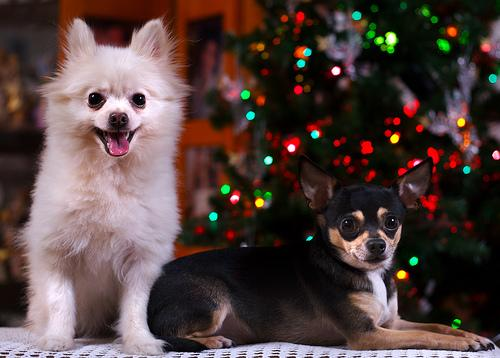

In [157]:
from PIL import Image

path_images_folder = r'D:\Utilisateurs\Damien\Documents\Test_code\test_python\OCR_projets\IML\P6_\Archives\images'
path_annotation_folder = r'D:\Utilisateurs\Damien\Documents\Test_code\test_python\OCR_projets\IML\P6_\Archives\annotation'


In [189]:
# sub_path = '\\'+ 'n02090379-redbone' + '\\'+ 'n02090379_4875' # Les 2 chiens sont annotés, malgré le fait qu'il semble qu'ils soient tout deux de races différentes
# sub_path = '\\'+ 'n02090379-redbone' + '\\'+'n02090379_3445' # 1 seul chien a été annoté (les 2 chiens et leur races sont clairement discernables et différentes)
sub_path = '\\'+ 'n02112018-Pomeranian' + '\\'+ 'n02112018_1158' # 1 seul chien a été annoté

In [190]:
path_img_test = path_images_folder + sub_path + '.jpg'
path_annotation = path_annotation_folder + sub_path

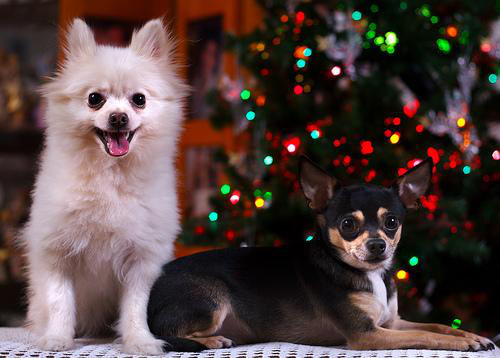

In [191]:
#read the image
im = Image.open(path_img_test)

#show image
# im.show()
im

In [192]:
with open(path_annotation) as file:

   file_annotation = file.read()

   print(file_annotation)

<annotation>
	<folder>02112018</folder>
	<filename>n02112018_1158</filename>
	<source>
		<database>ImageNet database</database>
	</source>
	<size>
		<width>500</width>
		<height>358</height>
		<depth>3</depth>
	</size>
	<segment>0</segment>
	<object>
		<name>Pomeranian</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>21</xmin>
			<ymin>16</ymin>
			<xmax>188</xmax>
			<ymax>355</ymax>
		</bndbox>
	</object>
</annotation>


 On pourrait évaluer l'accuracy sur le nmbre de chiens détecter dans une image.

In [58]:
nb_dog_detect_accuracy = accuracy_score(df_data_test['nb_race_x'], df_data_test['nb_race_y'], normalize=True)
nb_dog_detect_accuracy

0.8754563894523326

In [59]:
# pd.merge(df_yolo_dog_detect,df_dog_annotation[['','','']],how='left', on='file_name')

In [60]:
df_yolo_dog_detect[['xpm','ypm','xpw','yph']]

,xpm,ypm,xpw,yph
0,0.500000,0.528000,0.996000,0.933333
1,0.505000,0.464000,0.674000,0.869333
2,0.656818,0.490909,0.686364,0.981818
3,0.463000,0.480000,0.830000,0.704000
4,0.479000,0.513000,0.950000,0.974000
...,...,...,...,...
2148,0.462000,0.562667,0.292000,0.485333
2149,0.641000,0.743017,0.702000,0.497207
2150,0.204000,0.509777,0.368000,0.958101
2151,0.551389,0.493363,0.897222,0.809735


In [61]:
# Calcul des boundings box yolo au format des annotations
list_bb_yolo = []

for img_name in df_data_test["file_name"]:
    df_xp = df_data_test[(df_data_test["file_name"]==img_name) ][['xpm','ypm','xpw','yph']]
    xp = df_xp.values[0]
    
    df_wh = df_data_test[(df_data_test["file_name"]==img_name) ][['width','height']]
    wh = df_wh.values[0]
    
    xm = xp2xm(xp,wh[0],wh[1])
    bb_yolo = xm2bb(xm) #[bbmin_x,bbmin_y,bbmax_x,bbmax_y]
    bb_yolo_int = [int(x) for x in bb_yolo]
    
    list_bb_yolo.append(bb_yolo_int)
    
#     df_bb_annotation = df_data_test[(df_data_test["file_name"]==img_name) ][['xmin','ymin','xmax','ymax']]
#     bb_annotation = df_bb_annotation.values[0]
    
#     iou = bb_intersection_over_union(boxA, boxB)



In [62]:
df_data_test = df_data_test.assign(bb_yolo = list_bb_yolo)
df_data_test

,file_name,class_yolo,xpm,ypm,xpw,yph,probability,nb_race_x,xmin,ymin,xmax,ymax,name_race,width,height,class_string,path_to_img,nb_race_y,bb_yolo
0,n02097130_2821,16,0.500000,0.528000,0.996000,0.933333,0.958085,1,0,22,499,374,giant_schnauzer,500,375,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[1, 23, 499, 372]"
1,n02097130_5891,16,0.505000,0.464000,0.674000,0.869333,0.967097,1,84,14,419,336,giant_schnauzer,500,375,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[84, 11, 421, 336]"
2,n02106382_865,16,0.656818,0.490909,0.686364,0.981818,0.514949,1,66,0,219,162,Bouvier_des_Flandres,220,165,n02106382,/kaggle/input/dog-race-images/images/images/n0...,1,"[68, 0, 220, 161]"
3,n02097130_4265,16,0.463000,0.480000,0.830000,0.704000,0.338776,1,29,48,439,313,giant_schnauzer,500,375,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[24, 48, 439, 312]"
4,n02097130_4518,16,0.479000,0.513000,0.950000,0.974000,0.945232,1,1,15,462,498,giant_schnauzer,500,500,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[2, 13, 477, 500]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2460,n02112018_12953,16,0.462000,0.562667,0.292000,0.485333,0.935491,1,158,119,306,301,Pomeranian,500,375,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[158, 120, 304, 302]"
2461,n02112018_1158,16,0.641000,0.743017,0.702000,0.497207,0.888464,2,21,16,188,355,Pomeranian,500,358,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[145, 177, 496, 355]"
2462,n02112018_1158,16,0.204000,0.509777,0.368000,0.958101,0.916298,2,21,16,188,355,Pomeranian,500,358,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[145, 177, 496, 355]"
2463,n02112018_354,16,0.551389,0.493363,0.897222,0.809735,0.536818,1,35,18,359,204,Pomeranian,360,226,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[37, 19, 360, 203]"


In [63]:
# Calcul de l'IOU

list_iou = []

for img_name in df_data_test["file_name"]:
    
    df_bb_annotation = df_data_test[(df_data_test["file_name"]==img_name) ][['xmin','ymin','xmax','ymax']]
    bb_annotation = df_bb_annotation.values[0]
    
    df_bb_yolo = df_data_test[(df_data_test["file_name"]==img_name) ]['bb_yolo']
    bb_yolo = df_bb_yolo.values[0]
    
    iou = bb_intersection_over_union(bb_annotation, bb_yolo)
    list_iou.append(iou)


In [64]:
df_data_test['bb_yolo']

0          [1, 23, 499, 372]
1         [84, 11, 421, 336]
2          [68, 0, 220, 161]
3         [24, 48, 439, 312]
4          [2, 13, 477, 500]
                ...         
2460    [158, 120, 304, 302]
2461    [145, 177, 496, 355]
2462    [145, 177, 496, 355]
2463      [37, 19, 360, 203]
2464     [185, 40, 499, 334]
Name: bb_yolo, Length: 2465, dtype: object

In [65]:
list_iou[0:3]

[0.9895184135977337, 0.9849348386394162, 0.9746675110829639]

In [66]:
len(list_iou)

2465

In [67]:
df_data_test = df_data_test.assign(iou = list_iou)
df_data_test

,file_name,class_yolo,xpm,ypm,xpw,yph,probability,nb_race_x,xmin,ymin,xmax,ymax,name_race,width,height,class_string,path_to_img,nb_race_y,bb_yolo,iou
0,n02097130_2821,16,0.500000,0.528000,0.996000,0.933333,0.958085,1,0,22,499,374,giant_schnauzer,500,375,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[1, 23, 499, 372]",0.989518
1,n02097130_5891,16,0.505000,0.464000,0.674000,0.869333,0.967097,1,84,14,419,336,giant_schnauzer,500,375,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[84, 11, 421, 336]",0.984935
2,n02106382_865,16,0.656818,0.490909,0.686364,0.981818,0.514949,1,66,0,219,162,Bouvier_des_Flandres,220,165,n02106382,/kaggle/input/dog-race-images/images/images/n0...,1,"[68, 0, 220, 161]",0.974668
3,n02097130_4265,16,0.463000,0.480000,0.830000,0.704000,0.338776,1,29,48,439,313,giant_schnauzer,500,375,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[24, 48, 439, 312]",0.984311
4,n02097130_4518,16,0.479000,0.513000,0.950000,0.974000,0.945232,1,1,15,462,498,giant_schnauzer,500,500,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[2, 13, 477, 500]",0.958552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2460,n02112018_12953,16,0.462000,0.562667,0.292000,0.485333,0.935491,1,158,119,306,301,Pomeranian,500,375,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[158, 120, 304, 302]",0.975925
2461,n02112018_1158,16,0.641000,0.743017,0.702000,0.497207,0.888464,2,21,16,188,355,Pomeranian,500,358,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[145, 177, 496, 355]",0.070164
2462,n02112018_1158,16,0.204000,0.509777,0.368000,0.958101,0.916298,2,21,16,188,355,Pomeranian,500,358,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[145, 177, 496, 355]",0.070164
2463,n02112018_354,16,0.551389,0.493363,0.897222,0.809735,0.536818,1,35,18,359,204,Pomeranian,360,226,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[37, 19, 360, 203]",0.980233


#### N'étant pas sûr des boundings boxs prisent en compte lors du calcul des iou pour plusieurs détections et annotations dans une seule image, on décide de ne regarder que lorsqu'on a une seule détection et une seule annotation.

In [68]:
df_data_test[(df_data_test["nb_race_x"]==1) & (df_data_test["nb_race_y"]==1)]

,file_name,class_yolo,xpm,ypm,xpw,yph,probability,nb_race_x,xmin,ymin,xmax,ymax,name_race,width,height,class_string,path_to_img,nb_race_y,bb_yolo,iou
0,n02097130_2821,16,0.500000,0.528000,0.996000,0.933333,0.958085,1,0,22,499,374,giant_schnauzer,500,375,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[1, 23, 499, 372]",0.989518
1,n02097130_5891,16,0.505000,0.464000,0.674000,0.869333,0.967097,1,84,14,419,336,giant_schnauzer,500,375,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[84, 11, 421, 336]",0.984935
2,n02106382_865,16,0.656818,0.490909,0.686364,0.981818,0.514949,1,66,0,219,162,Bouvier_des_Flandres,220,165,n02106382,/kaggle/input/dog-race-images/images/images/n0...,1,"[68, 0, 220, 161]",0.974668
3,n02097130_4265,16,0.463000,0.480000,0.830000,0.704000,0.338776,1,29,48,439,313,giant_schnauzer,500,375,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[24, 48, 439, 312]",0.984311
4,n02097130_4518,16,0.479000,0.513000,0.950000,0.974000,0.945232,1,1,15,462,498,giant_schnauzer,500,500,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[2, 13, 477, 500]",0.958552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2458,n02112018_5961,16,0.466000,0.522523,0.928000,0.924925,0.882958,1,0,20,457,332,Pomeranian,500,333,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[1, 20, 465, 328]",0.968366
2459,n02112018_11105,16,0.411458,0.512500,0.814583,0.869444,0.864450,1,3,26,388,271,Pomeranian,480,360,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[1, 28, 392, 340]",0.762821
2460,n02112018_12953,16,0.462000,0.562667,0.292000,0.485333,0.935491,1,158,119,306,301,Pomeranian,500,375,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[158, 120, 304, 302]",0.975925
2463,n02112018_354,16,0.551389,0.493363,0.897222,0.809735,0.536818,1,35,18,359,204,Pomeranian,360,226,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[37, 19, 360, 203]",0.980233


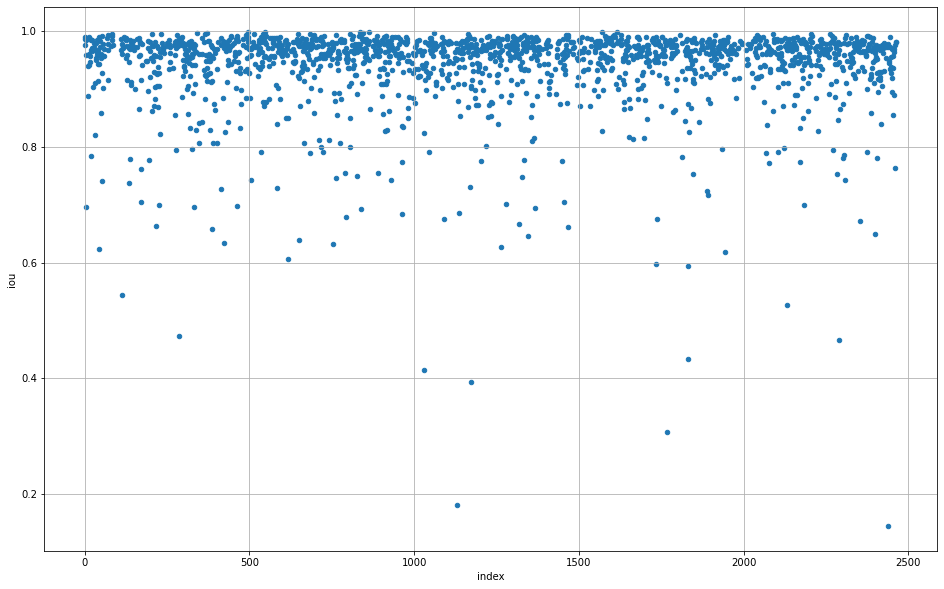

In [69]:
# Nuage de points de l'iou
df_data_test[(df_data_test["nb_race_x"]==1) & (df_data_test["nb_race_y"]==1)].reset_index().plot.scatter(x='index',y='iou',figsize=(16,10))
plt.grid()
plt.show()

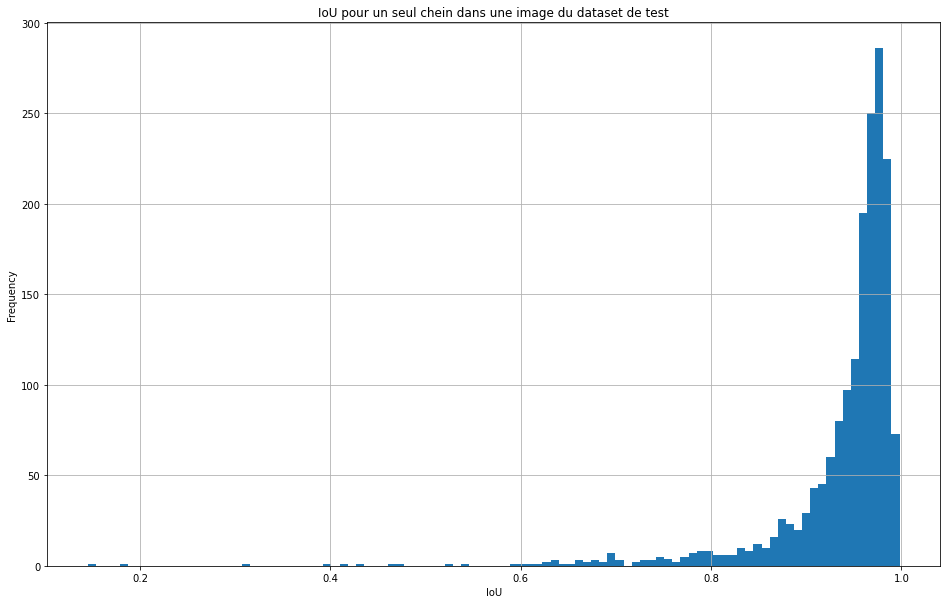

In [70]:
# Histogramme de l'iou
df_data_test[(df_data_test["nb_race_x"]==1) & (df_data_test["nb_race_y"]==1)]['iou'].plot.hist(bins=100,figsize=(16,10))
plt.xlabel('IoU')
plt.title('IoU pour un seul chein dans une image du dataset de test')
plt.grid()
plt.show()

La répartition de l'iou montre une majorité de valeurs prochent de 1, donnant l'idée que les détections de chiens sont assez bien localisées.

In [152]:
df_data_test[(df_data_test["nb_race_x"]==1) & (df_data_test["nb_race_y"]==1) & (df_data_test["iou"]>=0.8)]

,file_name,class_yolo,xpm,ypm,xpw,yph,probability,nb_race_x,xmin,ymin,xmax,ymax,name_race,width,height,class_string,path_to_img,nb_race_y,bb_yolo,iou
0,n02097130_2821,16,0.500000,0.528000,0.996000,0.933333,0.958085,1,0,22,499,374,giant_schnauzer,500,375,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[1, 23, 499, 372]",0.989518
1,n02097130_5891,16,0.505000,0.464000,0.674000,0.869333,0.967097,1,84,14,419,336,giant_schnauzer,500,375,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[84, 11, 421, 336]",0.984935
2,n02106382_865,16,0.656818,0.490909,0.686364,0.981818,0.514949,1,66,0,219,162,Bouvier_des_Flandres,220,165,n02106382,/kaggle/input/dog-race-images/images/images/n0...,1,"[68, 0, 220, 161]",0.974668
3,n02097130_4265,16,0.463000,0.480000,0.830000,0.704000,0.338776,1,29,48,439,313,giant_schnauzer,500,375,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[24, 48, 439, 312]",0.984311
4,n02097130_4518,16,0.479000,0.513000,0.950000,0.974000,0.945232,1,1,15,462,498,giant_schnauzer,500,500,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[2, 13, 477, 500]",0.958552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2457,n02090721_3811,16,0.767267,0.641000,0.297297,0.422000,0.834906,1,199,224,305,428,Irish_wolfhound,333,500,n02090721,/kaggle/input/dog-race-images/images/images/n0...,1,"[205, 215, 304, 426]",0.888986
2458,n02112018_5961,16,0.466000,0.522523,0.928000,0.924925,0.882958,1,0,20,457,332,Pomeranian,500,333,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[1, 20, 465, 328]",0.968366
2460,n02112018_12953,16,0.462000,0.562667,0.292000,0.485333,0.935491,1,158,119,306,301,Pomeranian,500,375,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[158, 120, 304, 302]",0.975925
2463,n02112018_354,16,0.551389,0.493363,0.897222,0.809735,0.536818,1,35,18,359,204,Pomeranian,360,226,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[37, 19, 360, 203]",0.980233


In [153]:
1641/1728

0.9496527777777778

On a 1641 images sur 1728 dont l'IoU est supérieur à 80%. Celà représente 95 % d'images sur celles choisises pour les calculs.

In [71]:
# nombre d'images dont la quantité de chien est différent entre yolo et annotation
df_data_test[df_data_test['nb_race_x'] != df_data_test['nb_race_y']]

,file_name,class_yolo,xpm,ypm,xpw,yph,probability,nb_race_x,xmin,ymin,xmax,ymax,name_race,width,height,class_string,path_to_img,nb_race_y,bb_yolo,iou
26,n02113978_2167,16,0.847500,0.245875,0.305000,0.485149,0.261195,2,32,39,169,296,Mexican_hairless,200,303,n02113978,/kaggle/input/dog-race-images/images/images/n0...,1,"[139, 1, 200, 148]",0.082427
27,n02113978_2167,16,0.505000,0.551155,0.700000,0.851485,0.956064,2,32,39,169,296,Mexican_hairless,200,303,n02113978,/kaggle/input/dog-race-images/images/images/n0...,1,"[139, 1, 200, 148]",0.082427
73,n02090721_4353,16,0.257743,0.535000,0.511062,0.854000,0.592422,2,205,33,450,465,Irish_wolfhound,452,500,n02090721,/kaggle/input/dog-race-images/images/images/n0...,3,"[0, 54, 231, 481]",0.057137
74,n02090721_4353,16,0.257743,0.535000,0.511062,0.854000,0.592422,2,63,51,271,435,Irish_wolfhound,452,500,n02090721,/kaggle/input/dog-race-images/images/images/n0...,3,"[0, 54, 231, 481]",0.057137
75,n02090721_4353,16,0.257743,0.535000,0.511062,0.854000,0.592422,2,0,230,152,438,Irish_wolfhound,452,500,n02090721,/kaggle/input/dog-race-images/images/images/n0...,3,"[0, 54, 231, 481]",0.057137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2396,n02096437_1511,16,0.396000,0.425393,0.788000,0.850785,0.787307,1,1,0,220,331,Dandie_Dinmont,500,382,n02096437,/kaggle/input/dog-race-images/images/images/n0...,2,"[1, 0, 395, 325]",0.561963
2442,n02104365_7629,16,0.129000,0.048000,0.250000,0.096000,0.311438,2,179,86,334,315,schipperke,500,375,n02104365,/kaggle/input/dog-race-images/images/images/n0...,1,"[2, 0, 127, 36]",0.000000
2443,n02104365_7629,16,0.514000,0.526667,0.324000,0.594667,0.562980,2,179,86,334,315,schipperke,500,375,n02104365,/kaggle/input/dog-race-images/images/images/n0...,1,"[2, 0, 127, 36]",0.000000
2461,n02112018_1158,16,0.641000,0.743017,0.702000,0.497207,0.888464,2,21,16,188,355,Pomeranian,500,358,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[145, 177, 496, 355]",0.070164


In [72]:
# nombre d'images dont la quantité de chien est différent entre yolo et annotation
df_data_test[df_data_test['nb_race_x'] != df_data_test['nb_race_y']]['file_name'].value_counts()

n02088466_9167     24
n02111129_314      12
n02115913_1047      8
n02110806_318       6
n02090721_4353      6
                   ..
n02096294_1629      2
n02105162_2636      2
n02109961_467       2
n02086079_23100     2
n02112018_1158      2
Name: file_name, Length: 108, dtype: int64

In [73]:
df_data_test[df_data_test['file_name'] == 'n02088466_9167']

,file_name,class_yolo,xpm,ypm,xpw,yph,probability,nb_race_x,xmin,ymin,xmax,ymax,name_race,width,height,class_string,path_to_img,nb_race_y,bb_yolo,iou
86,n02088466_9167,16,0.724,0.470667,0.092,0.146667,0.314922,6,14,119,271,308,bloodhound,500,375,n02088466,/kaggle/input/dog-race-images/images/images/n0...,4,"[339, 149, 385, 204]",0.0
87,n02088466_9167,16,0.724,0.470667,0.092,0.146667,0.314922,6,337,151,413,300,bloodhound,500,375,n02088466,/kaggle/input/dog-race-images/images/images/n0...,4,"[339, 149, 385, 204]",0.0
88,n02088466_9167,16,0.724,0.470667,0.092,0.146667,0.314922,6,68,163,157,333,bloodhound,500,375,n02088466,/kaggle/input/dog-race-images/images/images/n0...,4,"[339, 149, 385, 204]",0.0
89,n02088466_9167,16,0.724,0.470667,0.092,0.146667,0.314922,6,186,156,352,315,bloodhound,500,375,n02088466,/kaggle/input/dog-race-images/images/images/n0...,4,"[339, 149, 385, 204]",0.0
90,n02088466_9167,16,0.951,0.653333,0.098,0.176000,0.315412,6,14,119,271,308,bloodhound,500,375,n02088466,/kaggle/input/dog-race-images/images/images/n0...,4,"[339, 149, 385, 204]",0.0
91,n02088466_9167,16,0.951,0.653333,0.098,0.176000,0.315412,6,337,151,413,300,bloodhound,500,375,n02088466,/kaggle/input/dog-race-images/images/images/n0...,4,"[339, 149, 385, 204]",0.0
92,n02088466_9167,16,0.951,0.653333,0.098,0.176000,0.315412,6,68,163,157,333,bloodhound,500,375,n02088466,/kaggle/input/dog-race-images/images/images/n0...,4,"[339, 149, 385, 204]",0.0
93,n02088466_9167,16,0.951,0.653333,0.098,0.176000,0.315412,6,186,156,352,315,bloodhound,500,375,n02088466,/kaggle/input/dog-race-images/images/images/n0...,4,"[339, 149, 385, 204]",0.0
94,n02088466_9167,16,0.259,0.574667,0.446,0.488000,0.695000,6,14,119,271,308,bloodhound,500,375,n02088466,/kaggle/input/dog-race-images/images/images/n0...,4,"[339, 149, 385, 204]",0.0
95,n02088466_9167,16,0.259,0.574667,0.446,0.488000,0.695000,6,337,151,413,300,bloodhound,500,375,n02088466,/kaggle/input/dog-race-images/images/images/n0...,4,"[339, 149, 385, 204]",0.0


In [74]:
 df_yolo_dog_detect[df_yolo_dog_detect['file_name'] == 'n02088466_9167']

,file_name,class_yolo,xpm,ypm,xpw,yph,probability,nb_race
74,n02088466_9167,16,0.724,0.470667,0.092,0.146667,0.314922,6
75,n02088466_9167,16,0.951,0.653333,0.098,0.176000,0.315412,6
76,n02088466_9167,16,0.259,0.574667,0.446,0.488000,0.695000,6
77,n02088466_9167,16,0.528,0.628000,0.340,0.440000,0.722360,6
78,n02088466_9167,16,0.205,0.660000,0.234,0.434667,0.840430,6
79,n02088466_9167,16,0.750,0.661333,0.160,0.293333,0.846096,6


In [75]:
 df_dog_annotation[df_dog_annotation['file_name'] == 'n02088466_9167']

,file_name,xmin,ymin,xmax,ymax,name_race,width,height,class_string,path_to_img,nb_race
22080,n02088466_9167,14,119,271,308,bloodhound,500,375,n02088466,/kaggle/input/dog-race-images/images/images/n0...,4
22081,n02088466_9167,337,151,413,300,bloodhound,500,375,n02088466,/kaggle/input/dog-race-images/images/images/n0...,4
22082,n02088466_9167,68,163,157,333,bloodhound,500,375,n02088466,/kaggle/input/dog-race-images/images/images/n0...,4
22083,n02088466_9167,186,156,352,315,bloodhound,500,375,n02088466,/kaggle/input/dog-race-images/images/images/n0...,4


Pour chaque ligne à gauhe (yolo), on crée autant de lignes qu'à droite (annotation) d'où ici, 6x4 = 24 lignes pour cette image.

In [76]:
# nombre d'images dont la quantité de chien est différent entre yolo et annotation
df_data_test[df_data_test['nb_race_x'] == df_data_test['nb_race_y']]['file_name'].value_counts()

n02091831_3616    9
n02095889_6021    9
n02102973_273     9
n02088238_9778    9
n02093256_6158    9
                 ..
n02096051_3194    1
n02111889_6781    1
n02096051_5776    1
n02101006_3288    1
n02112018_1339    1
Name: file_name, Length: 1823, dtype: int64

In [77]:
 df_yolo_dog_detect[df_yolo_dog_detect['file_name'] == 'n02091831_3616']

,file_name,class_yolo,xpm,ypm,xpw,yph,probability,nb_race
1732,n02091831_3616,16,0.767,0.440000,0.306,0.346667,0.588264,3
1733,n02091831_3616,16,0.628,0.528000,0.284,0.432000,0.645660,3
1734,n02091831_3616,16,0.142,0.566667,0.256,0.440000,0.891210,3


In [78]:
 df_dog_annotation[df_dog_annotation['file_name'] == 'n02091831_3616']

,file_name,xmin,ymin,xmax,ymax,name_race,width,height,class_string,path_to_img,nb_race
11928,n02091831_3616,10,129,128,290,Saluki,500,375,n02091831,/kaggle/input/dog-race-images/images/images/n0...,3
11929,n02091831_3616,304,111,379,283,Saluki,500,375,n02091831,/kaggle/input/dog-race-images/images/images/n0...,3
11930,n02091831_3616,246,99,457,255,Saluki,500,375,n02091831,/kaggle/input/dog-race-images/images/images/n0...,3


In [79]:
df_data_test[(df_data_test["nb_race_x"]==1) & (df_data_test["nb_race_y"]==1)]['file_name'].value_counts()

n02097130_2821     1
n02102177_575      1
n02089973_1690     1
n02089973_3799     1
n02089973_1324     1
                  ..
n02105162_10351    1
n02112018_904      1
n02109961_8295     1
n02109961_7100     1
n02112018_1339     1
Name: file_name, Length: 1728, dtype: int64

#### Probabilité d'appartenir à la classe chien depuis la détection de yolo

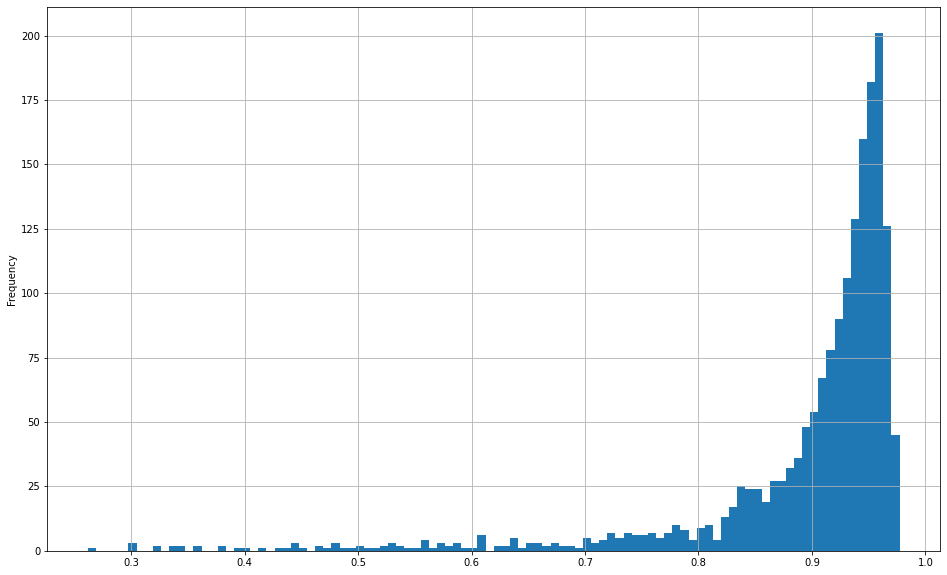

In [80]:
# Histogramme de l'iou
df_data_test[(df_data_test["nb_race_x"]==1) & (df_data_test["nb_race_y"]==1)]['probability'].plot.hist(bins=100,figsize=(16,10))
plt.grid()
plt.show()

#### Courbe IOU-Probability (dog)

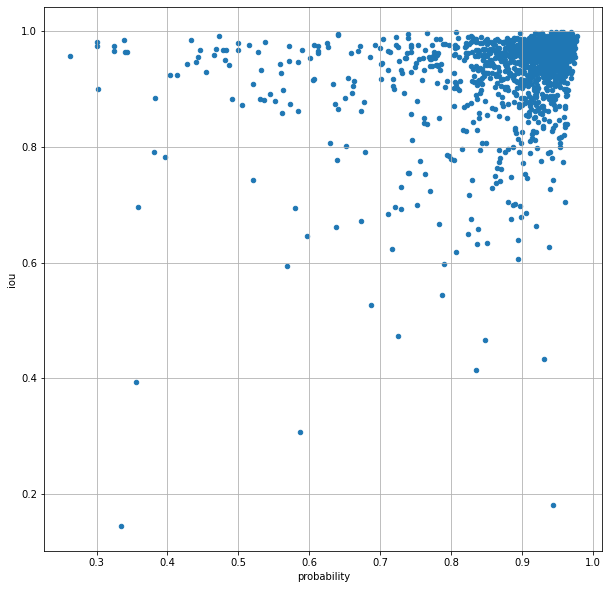

In [81]:
# Nuage de points de l'iou par rapport à la probabilité d'être un chien
df_data_test[(df_data_test["nb_race_x"]==1) & (df_data_test["nb_race_y"]==1)].reset_index().plot.scatter(x='probability',y='iou',figsize=(10,10))
plt.grid()
plt.show()

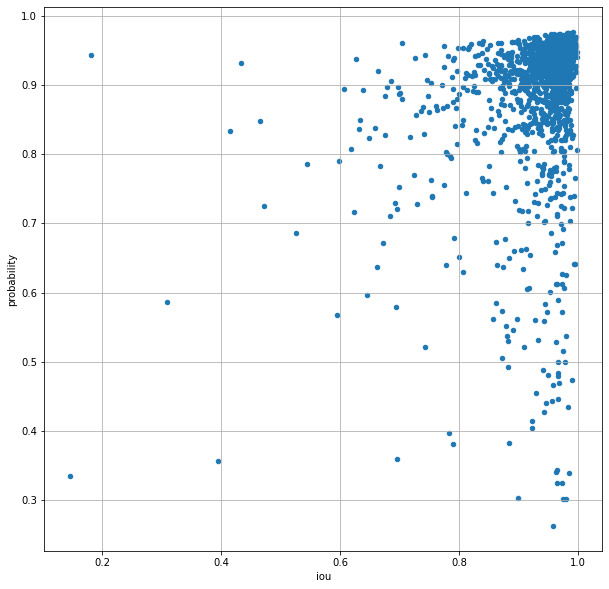

In [82]:
# Nuage de points de l'iou par rapport à la probabilité d'être un chien
df_data_test[(df_data_test["nb_race_x"]==1) & (df_data_test["nb_race_y"]==1)].reset_index().plot.scatter(x='iou',y='probability',figsize=(10,10))
plt.grid()
plt.show()

A quoi ressemble les images dont la probabilité d'être un chien est basse?

In [83]:
def precision_at(threshold, iou):
    """
    Computes the precision at a given threshold.

    Args:
        threshold (float): Threshold.
        iou (np array [n_truths x n_preds]): IoU matrix.

    Returns:
        int: Number of true positives,
        int: Number of false positives,
        int: Number of false negatives.
    """
    matches = iou > threshold
    true_positives = np.sum(matches, axis=1) >= 1  # Correct objects
    false_negatives = np.sum(matches, axis=1) == 0  # Missed objects
    false_positives = np.sum(matches, axis=0) == 0  # Extra objects
    tp, fp, fn = (
        np.sum(true_positives),
        np.sum(false_positives),
        np.sum(false_negatives),
    )
    return tp, fp, fn

In [84]:
def precision_at2(threshold, iou):
    """
    Computes the precision at a given threshold.

    Args:
        threshold (float): Threshold.
        iou (np array [n_truths x n_preds]): IoU matrix.

    Returns:
        int: Number of true positives,
        int: Number of false positives,
        int: Number of false negatives.
    """
    matches = iou > threshold
    true_positives = np.sum(matches) >= 1  # Correct objects
    false_negatives = np.sum(matches) == 0  # Missed objects
    false_positives = np.sum(matches) == 0  # Extra objects
    tp, fp, fn = (
        np.sum(true_positives),
        np.sum(false_positives),
        np.sum(false_negatives),
    )
    return tp, fp, fn

In [85]:
list_iou = df_data_test['iou'].tolist()

In [86]:
# precision_at(0.5, np.array(list_iou))

In [87]:
np.array(list_iou) >=0.3

array([ True,  True,  True, ..., False,  True,  True])

In [88]:
precision_at2(0.5, np.array(list_iou))

(1, 0, 0)

In [89]:
# from sklearn.metrics import precision_recall_curve
# precision, recall, thresholds = precision_recall_curve(yyy[0][0],yyy[0][1],0 ) #y_true, y_scores

In [90]:
from sklearn.metrics import precision_recall_curve
# (y_true, probas_pred, *, pos_label=None, sample_weight=None)


precision, recall, thresholds = precision_recall_curve(yyyy[0][2],yyyy[0][1],pos_label = 10 ) #y_true, y_scores
## --> il faut le score en probabilité des 120 classes par images et non seuelemtn le meilleur score de l'image
## y_scores ici doit être celui de la classe i défini par pos_label = i

# n_thresholds = len(np.unique(probas_pred)).

In [91]:
precision

array([1.06951872e-02, 2.16099406e-03, 5.47945205e-04, 5.54016620e-04,
       5.58347292e-04, 5.62429696e-04, 5.66572238e-04, 5.69800570e-04,
       5.74052813e-04, 5.79374276e-04, 5.88581519e-04, 5.94883998e-04,
       5.99520384e-04, 6.04594921e-04, 6.11246944e-04, 6.17283951e-04,
       6.26174076e-04, 6.36132316e-04, 6.43086817e-04, 6.47668394e-04,
       6.58761528e-04, 6.65778961e-04, 6.76132522e-04, 6.82128240e-04,
       6.87757909e-04, 6.97836706e-04, 7.07213579e-04, 7.17360115e-04,
       7.25689405e-04, 7.36377025e-04, 7.47943156e-04, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

In [92]:
recall

array([1.  , 0.2 , 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  ])

In [93]:
thresholds

array([ 10,  11,  12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,
        23,  24,  25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,
        36,  37,  38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,
        49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,
        62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,
        75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,
        88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100,
       101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113,
       114, 115, 116, 117, 118, 119], dtype=int64)

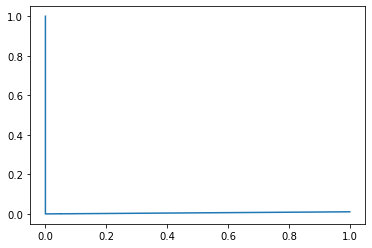

In [94]:
plt.plot(recall, precision)

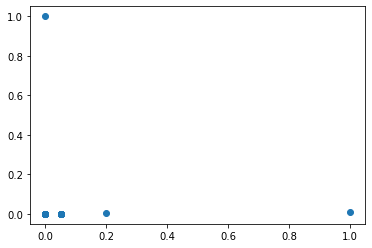

In [95]:
plt.scatter(recall, precision)

In [96]:
len(yyyy[0][1])

2052

In [97]:
len(thresholds)

110

In [98]:
AP = np.sum((recall[:-1] - recall[1:]) * precision[:-1])
print(AP)

0.00891769599902628


In [99]:
import sklearn.metrics

def precision_recall_curve_scratch(y_true, pred_scores, thresholds):
    precisions = []
    recalls = []
    
    for threshold in thresholds:
        y_pred = ["positive" if score >= threshold else "negative" for score in pred_scores]

        precision = sklearn.metrics.precision_score(y_true=y_true, y_pred=y_pred, pos_label="positive")
        recall = sklearn.metrics.recall_score(y_true=y_true, y_pred=y_pred, pos_label="positive")
        
        precisions.append(precision)
        recalls.append(recall)

    return precisions, recalls

In [100]:
import sklearn.metrics

def precision_recall_curve_scratch(y_true, pred_scores, thresholds,pos_label):
    precisions = []
    recalls = []
    
    for threshold in thresholds:
        y_pred = [pos_label if score >= threshold else 999 for score in pred_scores]
        print(y_pred[0:5])
        precision = sklearn.metrics.precision_score(y_true=y_true, y_pred=y_pred, labels=[pos_label],average='micro')
        recall = sklearn.metrics.recall_score(y_true=y_true, y_pred=y_pred, labels=[pos_label],average='micro')
        
        precisions.append(precision)
        recalls.append(recall)

    return precisions, recalls

In [101]:
# precision, recall = precision_recall_curve_scratch(yyy[0][0],y_score_random,[0.2,0.4,0.6,0.8],10 ) #y_true, y_scores

In [102]:
precision

array([1.06951872e-02, 2.16099406e-03, 5.47945205e-04, 5.54016620e-04,
       5.58347292e-04, 5.62429696e-04, 5.66572238e-04, 5.69800570e-04,
       5.74052813e-04, 5.79374276e-04, 5.88581519e-04, 5.94883998e-04,
       5.99520384e-04, 6.04594921e-04, 6.11246944e-04, 6.17283951e-04,
       6.26174076e-04, 6.36132316e-04, 6.43086817e-04, 6.47668394e-04,
       6.58761528e-04, 6.65778961e-04, 6.76132522e-04, 6.82128240e-04,
       6.87757909e-04, 6.97836706e-04, 7.07213579e-04, 7.17360115e-04,
       7.25689405e-04, 7.36377025e-04, 7.47943156e-04, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

In [103]:
recall

array([1.  , 0.2 , 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  ])

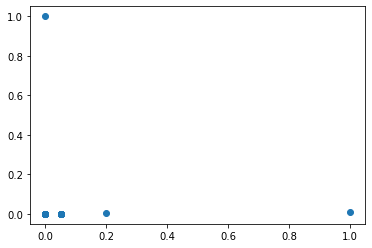

In [104]:
plt.scatter(recall, precision)

In [105]:
import sklearn.metrics
from sklearn.metrics import precision_recall_fscore_support
# classification_report =  precision_recall_fscore_support


def pr_curve(y_true, pred_scores, thresholds,pos_label):
    precisions = []
    recalls = []
    
    for threshold in thresholds:
        y_pred = [pos_label if score >= threshold else 999 for score in pred_scores]
        print(y_pred[0:5])
        
        #cr_list = []
        cr_ds_test = precision_recall_fscore_support(y_true=y_true, y_pred=y_pred, labels = [pos_label],average='micro')
    
        precisions.append(cr_ds_test[0])
        recalls.append(cr_ds_test[1])

    return precisions, recalls

In [106]:
# precision, recall = pr_curve(yyyy[0][2],y_score_random,[0.2,0.4,0.6,0.8],10 ) #y_true, y_scores

NameError: name 'y_score_random' is not defined

In [ ]:
# precision

In [ ]:
# recall

In [ ]:
# plt.scatter(recall, precision)

In [ ]:
# [ds_test,ds_test_new,ds_test_hs,ds_test_yolo,ds_test_annotation]

In [ ]:
# def get_predictions_data_y(dataset):
#     # Retourne la liste des labels (numéro de la classe) des prédictions et d'un ensemble de données labellisées
    
#     y_pred = [] #np.array([])
#     y_labels = [] # np.array([])
#     y_proba = [] # np.array([])
#     list_y_proba_class = []
    
#     #dataset_size = dataset.cardinality().numpy()
#     for images, labels in dataset.take(dataset.cardinality().numpy()): #ds_full.skip(train_size).skip(val_size): 
#         for i in range(len(images)): # le dernier batch n'est pas remplie de la taille batch_size = 32, mais de 4 images
#             [dog_proba,dog_class,dog_race] = img2pred(images[i],model_net) #[dog_proba,dog_class,dog_race] = img2pred(images[i])
            
#             img_array = tf.keras.utils.img_to_array(images[i]) #img = image[0]
#             img_array = tf.expand_dims(img_array, 0) # Create a batch
#             y_proba_class = model_net.predict(img_array)
        
#             y_pred.append(dog_class) #np.concatenate([y_pred, dog_class])
#             y_proba.append(dog_proba) # np.concatenate([y_proba, dog_proba])
#             y_labels.append(np.argmax(labels[i].numpy(), axis=-1)) # np.concatenate([y_labels, np.argmax(labels[i].numpy(), axis=-1)])
#             list_y_proba_class.append(y_proba_class)
            
#     return y_proba, y_pred, y_labels, list_y_proba_class

In [ ]:
# import joblib
# YYYY = joblib.load(r"./YYYY") 

# # YYYY = [Y_test, Y_new, Y_hs, Y_yolo, Y_annotation]
# # Y_test = [y_proba, y_pred, y_labels, list_y_proba_class]

# yyyy = YYYY[2:5]

In [107]:

len(yyyy[0][3][0][0]) # indice 3: indice de l'input, indice 4:0 pour récupérer la liste des proba des 120 classees


120

In [108]:
n_classes = 120

In [109]:
from sklearn.preprocessing import label_binarize

i_method = 0 #0: baselie, 1: yolo, annotation:2

# Use label_binarize to be multi-label like settings
Y = label_binarize(yyyy[i_method][2], classes=range(n_classes))
n_classes = Y.shape[1]

In [110]:
y_score = np.transpose(yyyy[i_method][3]) #y_score[i] ou y_score[i][0] ou i correspond à la classe de i pour les N inputs

In [111]:
Y_test = Y

In [112]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.metrics import f1_score

# For each class
precision = dict()
recall = dict()
f1score = dict()
average_precision = dict()
F1 =  dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(Y_test[:, i], y_score[i][0])
    average_precision[i] = average_precision_score(Y_test[:, i],y_score[i][0])
#     f1score[i] = 2 * (precision[i] * recall[i]) / (precision[i] + recall[i])
#     F1[i] = f1_score(Y_test[:, i], y_score[i][0], average='micro')

# A "micro-average": quantifying score on all classes jointly
precision["micro"], recall["micro"], _ = precision_recall_curve(
    Y_test.ravel(), y_score.ravel()
)
# average_precision["micro"] = average_precision_score(Y_test, y_score, average="micro")

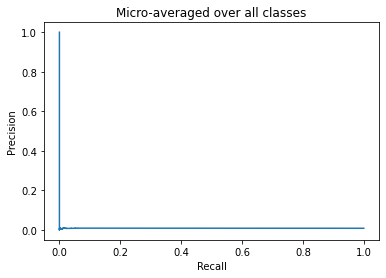

In [117]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay(
    recall=recall["micro"],
    precision=precision["micro"]
)
display.plot()
_ = display.ax_.set_title("Micro-averaged over all classes")

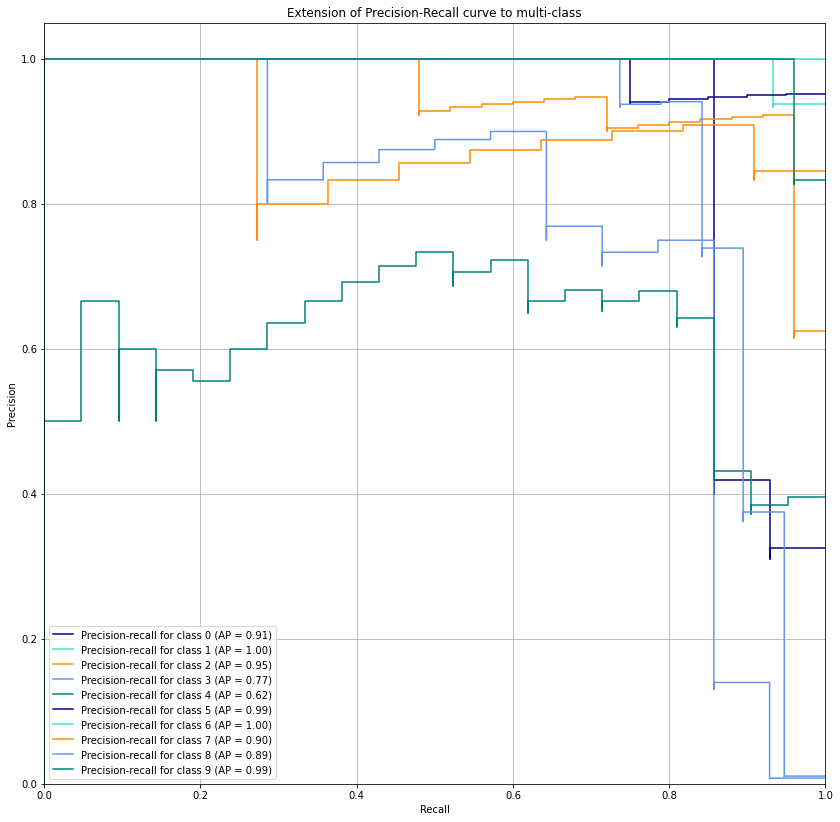

In [118]:
from itertools import cycle

# setup plot details
colors = cycle(["navy", "turquoise", "darkorange", "cornflowerblue", "teal"])

_, ax = plt.subplots(figsize=(14, 14))


# display.plot(ax=ax, name="Micro-average precision-recall", color="gold")

for i, color in zip(range(10), colors):
    display = PrecisionRecallDisplay(
        recall=recall[i],
        precision=precision[i],
        average_precision=average_precision[i],
    )
    display.plot(ax=ax, name=f"Precision-recall for class {i}", color=color)

# add the legend for the iso-f1 curves
handles, labels = display.ax_.get_legend_handles_labels()
# handles.extend([l])
# labels.extend(["iso-f1 curves"])
# set the legend and the axes
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.legend(handles=handles, labels=labels, loc="best")
ax.set_title("Extension of Precision-Recall curve to multi-class")
ax.grid()

plt.show()

In [119]:
average_precision

{0: 0.9103525881470367,
 1: 0.9958333333333333,
 2: 0.9497613591938938,
 3: 0.7681826618157601,
 4: 0.6150181453003714,
 5: 0.9867685144233134,
 6: 1.0000000000000002,
 7: 0.9008736213281667,
 8: 0.8949172296698666,
 9: 0.9933333333333336,
 10: 0.755750520997526,
 11: 0.6002858764126687,
 12: 0.9485904510137145,
 13: 0.9790616246498599,
 14: 0.9257154455043636,
 15: 0.6689217048413674,
 16: 0.8047355254898361,
 17: 0.8675425759793003,
 18: 0.916954426772766,
 19: 0.7794373461482582,
 20: 0.8635344550569541,
 21: 0.7877271149329974,
 22: 0.8970066970066968,
 23: 0.874961784634693,
 24: 0.9311309141511454,
 25: 0.9520033472207385,
 26: 0.835754450261823,
 27: 0.9385230542237464,
 28: 0.5074042711762049,
 29: 0.7755260336054348,
 30: 0.9796380090497738,
 31: 0.9332772790488827,
 32: 0.9567099567099568,
 33: 0.9045868347338935,
 34: 0.8831302439004829,
 35: 0.7943227200138843,
 36: 0.739531558582928,
 37: 0.9011631825144847,
 38: 0.7991185990058554,
 39: 0.9033679968387973,
 40: 0.83948424

In [120]:
list(average_precision.values())

[0.9103525881470367,
 0.9958333333333333,
 0.9497613591938938,
 0.7681826618157601,
 0.6150181453003714,
 0.9867685144233134,
 1.0000000000000002,
 0.9008736213281667,
 0.8949172296698666,
 0.9933333333333336,
 0.755750520997526,
 0.6002858764126687,
 0.9485904510137145,
 0.9790616246498599,
 0.9257154455043636,
 0.6689217048413674,
 0.8047355254898361,
 0.8675425759793003,
 0.916954426772766,
 0.7794373461482582,
 0.8635344550569541,
 0.7877271149329974,
 0.8970066970066968,
 0.874961784634693,
 0.9311309141511454,
 0.9520033472207385,
 0.835754450261823,
 0.9385230542237464,
 0.5074042711762049,
 0.7755260336054348,
 0.9796380090497738,
 0.9332772790488827,
 0.9567099567099568,
 0.9045868347338935,
 0.8831302439004829,
 0.7943227200138843,
 0.739531558582928,
 0.9011631825144847,
 0.7991185990058554,
 0.9033679968387973,
 0.8394842446052131,
 0.7572450586994777,
 0.9716666666666667,
 0.9913580246913581,
 0.9580740740740742,
 0.8760352962955518,
 0.5846870333214871,
 0.738280642911975

In [121]:
list(average_precision.keys())

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119]

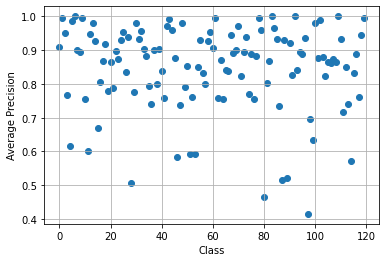

In [122]:
plt.scatter(list(average_precision.keys()), list(average_precision.values()))
plt.grid()
plt.xlabel('Class')
plt.ylabel('Average Precision')
plt.show()

In [123]:
mAP = np.mean(list(average_precision.values()))
mAP

0.8467370275042557

In [124]:
list_mAP = [0.847, 0.876, 0.903]

In [125]:
data_yolo_dog

,file_name,class_yolo,xpm,ypm,xpw,yph,probability
0,n02097130_2821,16,0.500000,0.528000,0.996000,0.933333,0.958085
1,n02097130_5891,16,0.505000,0.464000,0.674000,0.869333,0.967097
2,n02106382_865,16,0.656818,0.490909,0.686364,0.981818,0.514949
3,n02106382_865,21,0.654545,0.490909,0.681818,0.981818,0.588825
4,n02097130_4265,16,0.463000,0.480000,0.830000,0.704000,0.338776
...,...,...,...,...,...,...,...
4263,n02112018_1158,16,0.641000,0.743017,0.702000,0.497207,0.888464
4264,n02112018_1158,16,0.204000,0.509777,0.368000,0.958101,0.916298
4265,n02112018_354,14,0.555556,0.486726,0.883333,0.805310,0.387610
4266,n02112018_354,16,0.551389,0.493363,0.897222,0.809735,0.536818


In [126]:
data_yolo_dog.groupby('file_name')['class_yolo'].apply(list)

file_name
n02085620_11477     [0, 16]
n02085620_11696     [0, 16]
n02085620_11948        [16]
n02085620_12334     [7, 16]
n02085620_2793     [59, 16]
                     ...   
n02116738_8734         [23]
n02116738_8749         [16]
n02116738_8945         [16]
n02116738_9829         [16]
n02116738_9924     [16, 18]
Name: class_yolo, Length: 2046, dtype: object

In [127]:
df_detect = data_yolo_dog.groupby('file_name')['class_yolo'].apply(list)
df_detect

file_name
n02085620_11477     [0, 16]
n02085620_11696     [0, 16]
n02085620_11948        [16]
n02085620_12334     [7, 16]
n02085620_2793     [59, 16]
                     ...   
n02116738_8734         [23]
n02116738_8749         [16]
n02116738_8945         [16]
n02116738_9829         [16]
n02116738_9924     [16, 18]
Name: class_yolo, Length: 2046, dtype: object

In [128]:
df_detect = data_yolo_dog.groupby('file_name')['class_yolo'].apply(list).reset_index(name='class_detected')
df_detect

,file_name,class_detected
0,n02085620_11477,"[0, 16]"
1,n02085620_11696,"[0, 16]"
2,n02085620_11948,[16]
3,n02085620_12334,"[7, 16]"
4,n02085620_2793,"[59, 16]"
...,...,...
2041,n02116738_8734,[23]
2042,n02116738_8749,[16]
2043,n02116738_8945,[16]
2044,n02116738_9829,[16]


n02116738_8734
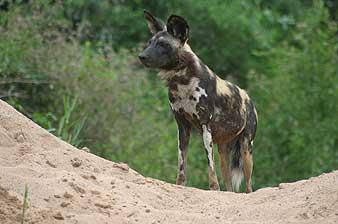

In [129]:
# df_detect[df_detect['class_detected'] == value for value in df_detect['class_detected'] if 16 in value]

In [130]:
# list_index_dog = []

# for value in df_detect['class_detected']:
#     if 16 in value:
        

In [131]:
list_index_nodog = []

for i in range(df_detect['class_detected'].shape[0]):
    if 16 not in df_detect['class_detected'][i]:
        list_index_nodog.append(i)
len(list_index_nodog)

115

In [132]:
list_index_nodog

[13,
 38,
 45,
 103,
 163,
 167,
 174,
 175,
 182,
 273,
 319,
 332,
 346,
 351,
 355,
 393,
 398,
 408,
 414,
 417,
 469,
 471,
 473,
 479,
 487,
 508,
 543,
 546,
 551,
 585,
 655,
 676,
 694,
 704,
 715,
 719,
 722,
 838,
 843,
 844,
 886,
 983,
 985,
 990,
 993,
 996,
 998,
 1045,
 1110,
 1232,
 1239,
 1257,
 1258,
 1266,
 1267,
 1268,
 1271,
 1272,
 1276,
 1285,
 1295,
 1309,
 1326,
 1328,
 1330,
 1331,
 1334,
 1335,
 1348,
 1355,
 1384,
 1396,
 1459,
 1465,
 1498,
 1583,
 1587,
 1608,
 1611,
 1675,
 1691,
 1701,
 1771,
 1803,
 1806,
 1811,
 1813,
 1815,
 1816,
 1818,
 1819,
 1831,
 1847,
 1853,
 1857,
 1910,
 1929,
 1938,
 1947,
 1959,
 1965,
 1986,
 1987,
 2000,
 2015,
 2016,
 2017,
 2019,
 2027,
 2029,
 2030,
 2036,
 2038,
 2040,
 2041]

In [133]:
df_detect['class_detected'][4]

[59, 16]

In [134]:
df_detect['class_detected'][list_index_nodog]

13        [0, 18, 0]
38           [0, 14]
45              [77]
103     [77, 77, 77]
163             [17]
            ...     
2030        [21, 18]
2036            [21]
2038        [22, 17]
2040            [21]
2041            [23]
Name: class_detected, Length: 115, dtype: object

In [135]:
df_detect.loc[list_index_nodog]

,file_name,class_detected
13,n02085620_9414,"[0, 18, 0]"
38,n02085936_2627,"[0, 14]"
45,n02085936_5582,[77]
103,n02086646_32,"[77, 77, 77]"
163,n02088094_10822,[17]
...,...,...
2030,n02116738_2192,"[21, 18]"
2036,n02116738_6563,[21]
2038,n02116738_7340,"[22, 17]"
2040,n02116738_8696,[21]


In [136]:
df_yolo_dog_detect

,file_name,class_yolo,xpm,ypm,xpw,yph,probability,nb_race
0,n02097130_2821,16,0.500000,0.528000,0.996000,0.933333,0.958085,1
1,n02097130_5891,16,0.505000,0.464000,0.674000,0.869333,0.967097,1
2,n02106382_865,16,0.656818,0.490909,0.686364,0.981818,0.514949,1
3,n02097130_4265,16,0.463000,0.480000,0.830000,0.704000,0.338776,1
4,n02097130_4518,16,0.479000,0.513000,0.950000,0.974000,0.945232,1
...,...,...,...,...,...,...,...,...
2148,n02112018_12953,16,0.462000,0.562667,0.292000,0.485333,0.935491,1
2149,n02112018_1158,16,0.641000,0.743017,0.702000,0.497207,0.888464,2
2150,n02112018_1158,16,0.204000,0.509777,0.368000,0.958101,0.916298,2
2151,n02112018_354,16,0.551389,0.493363,0.897222,0.809735,0.536818,1


In [137]:
len(yyyy[0][0])

2052

The f1 metric measures the balance between precision and recall. When the value of f1 is high, this means both the precision and recall are high. A lower f1 score means a greater imbalance between precision and recall.

According to the previous example, the f1 is calculated according to the code below. According to the values in the f1 list, the highest score is 0.82352941. It is the 6th element in the list (i.e. index 5). The 6th elements in the recalls and precisions lists are 0.778 and 0.875, respectively. The corresponding threshold value is 0.45.

In [138]:
# f1 = 2 * ((np.array(precisions) * np.array(recalls)) / (np.array(precisions) + np.array(recalls)))

Accuracy & mAP

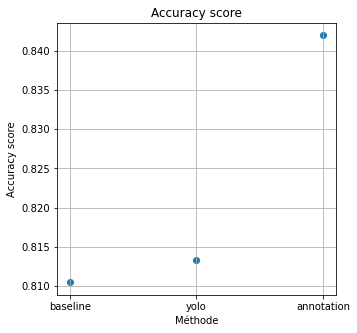

In [139]:
plt.figure(figsize=(5,5))
plt.scatter(list_methods,accuracy_list)
plt.xlabel("Méthode")
plt.ylabel('Accuracy score')
plt.title('Accuracy score')
# plt.legend(['baseline','yolo','annotation'])
plt.grid()

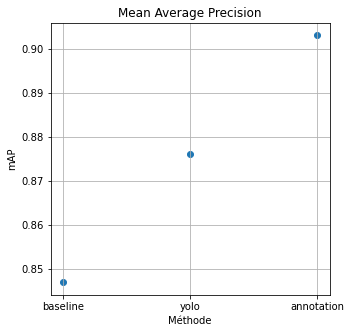

In [140]:
plt.figure(figsize=(5,5))
plt.scatter(list_methods,list_mAP)
plt.xlabel("Méthode")
plt.ylabel('mAP')
plt.title('Mean Average Precision')
# plt.legend(['baseline','yolo','annotation'])
plt.grid()

In [141]:
len(list_iou)

2465

In [142]:
df_data_test[(df_data_test["nb_race_x"]==1) & (df_data_test["nb_race_y"]==1)]

,file_name,class_yolo,xpm,ypm,xpw,yph,probability,nb_race_x,xmin,ymin,xmax,ymax,name_race,width,height,class_string,path_to_img,nb_race_y,bb_yolo,iou
0,n02097130_2821,16,0.500000,0.528000,0.996000,0.933333,0.958085,1,0,22,499,374,giant_schnauzer,500,375,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[1, 23, 499, 372]",0.989518
1,n02097130_5891,16,0.505000,0.464000,0.674000,0.869333,0.967097,1,84,14,419,336,giant_schnauzer,500,375,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[84, 11, 421, 336]",0.984935
2,n02106382_865,16,0.656818,0.490909,0.686364,0.981818,0.514949,1,66,0,219,162,Bouvier_des_Flandres,220,165,n02106382,/kaggle/input/dog-race-images/images/images/n0...,1,"[68, 0, 220, 161]",0.974668
3,n02097130_4265,16,0.463000,0.480000,0.830000,0.704000,0.338776,1,29,48,439,313,giant_schnauzer,500,375,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[24, 48, 439, 312]",0.984311
4,n02097130_4518,16,0.479000,0.513000,0.950000,0.974000,0.945232,1,1,15,462,498,giant_schnauzer,500,500,n02097130,/kaggle/input/dog-race-images/images/images/n0...,1,"[2, 13, 477, 500]",0.958552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2458,n02112018_5961,16,0.466000,0.522523,0.928000,0.924925,0.882958,1,0,20,457,332,Pomeranian,500,333,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[1, 20, 465, 328]",0.968366
2459,n02112018_11105,16,0.411458,0.512500,0.814583,0.869444,0.864450,1,3,26,388,271,Pomeranian,480,360,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[1, 28, 392, 340]",0.762821
2460,n02112018_12953,16,0.462000,0.562667,0.292000,0.485333,0.935491,1,158,119,306,301,Pomeranian,500,375,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[158, 120, 304, 302]",0.975925
2463,n02112018_354,16,0.551389,0.493363,0.897222,0.809735,0.536818,1,35,18,359,204,Pomeranian,360,226,n02112018,/kaggle/input/dog-race-images/images/images/n0...,1,"[37, 19, 360, 203]",0.980233


In [143]:
list_iou_onedog = df_data_test[(df_data_test["nb_race_x"]==1) & (df_data_test["nb_race_y"]==1)]['iou'].tolist()

In [144]:
list_class_yolo_onedog = df_data_test[(df_data_test["nb_race_x"]==1) & (df_data_test["nb_race_y"]==1)]['class_yolo'].tolist()

In [145]:
prc_iou = precision_recall_curve(list_class_yolo_onedog,list_iou_onedog, pos_label=16)

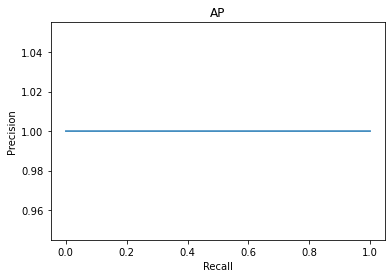

In [146]:
display = PrecisionRecallDisplay(
    recall=prc_iou[1],
    precision=prc_iou[0]
)
display.plot()
_ = display.ax_.set_title("AP")

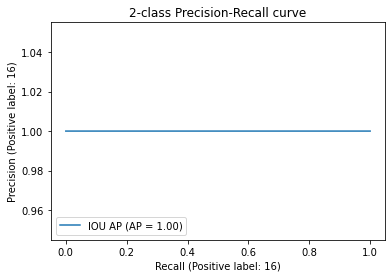

In [147]:
display = PrecisionRecallDisplay.from_predictions(list_class_yolo_onedog,list_iou_onedog, name="IOU AP", pos_label=16)
_ = display.ax_.set_title("2-class Precision-Recall curve")

In [149]:
2052/2153

0.9530887134231305